# Modélisation du bruit de la chaîne ADC

In [274]:
# Configuration of the simulation

## Constants
Fref = 125e6
Tmux = 34
code_fast = 0  #cas de test Laurent
code_fine = 0  #cas de test Laurent

## Configuration dependent variables
#Fs, data_filename_ext = Fref, '_Fref.txt'
Fs, data_filename_ext = Fref / (20), '_Frow.txt'
#Fs, data_filename_ext = Fref / (20 * Tmux), '_Fframe.txt'
#code_coarse = 1023    #cas de test Laurent
code_coarse = 0  #cas de test Laurent


In [275]:
import types

import numpy as np
from scipy import constants


### Fonctions ###
def Celsius2Kelvin(TC):
    TK = TC + constants.zero_Celsius
    return TK


def thermal_noise(R, TK):
    en = np.sqrt(4 * constants.Boltzmann * R * TK)
    return en


def shot_noise(I):
    inn = np.sqrt(2 * constants.elementary_charge * I)
    return inn


def quantization_noise(Vpp, N, Fs):
    LSB = Vpp / 2 ** N
    RMS_q = LSB / np.sqrt(12)
    e_q = RMS_q / np.sqrt(Fs / 2)
    return e_q, RMS_q, LSB


def aliasing(noise_func, analog_bw, fs, n):
    if not isinstance(noise_func, types.FunctionType):
        print("noise_func n'est pas une fonction")
        return

    f_nyq = fs / 2

    if analog_bw < f_nyq:
        print("La bande analogique est inférieure à la fréquence de Nyquist")
        return

    #freqs numériques
    f_num = np.unique(np.round(np.logspace(0, np.ceil(np.log10(f_nyq)), n)))  #arrondi au Hz et unique
    f_num = f_num[f_num < f_nyq]
    f_num = np.append(f_num, f_nyq)  #on est sûr de pas dépasser la fréquence de nyquist et d'avoir un point dessus
    #on ajoute les repliement "impaire" Fs-f
    f_num = np.unique(np.sort(np.append(f_num, fs - f_num)))

    # Fréquence analogique (Hz)
    # ce sont les fréquences numériques périodisée sur toute la bande
    k_alias_max = np.ceil(analog_bw / fs)

    # Construction des alias
    k_alias = np.arange(0, k_alias_max + 1)[:, None]  # vecteur colonne
    f_analogique = f_num + k_alias * fs  # ajoute tous les multiples de Fs
    f_analogique = f_analogique[(f_analogique <= analog_bw)]  # ne garde que les fréquences inférieure

    # Tri final
    f_analogique = np.unique(
        np.sort(f_analogique))  #on s'assure de l'unicité (cas où on a une freq à 0 et Fs par exemple)

    # ==== CALCUL ====

    #repliement fréquentiel
    f_modulo = np.mod(f_analogique, fs)
    f_repliee = np.where(f_modulo > f_nyq, fs - f_modulo, f_modulo)

    #indices des fréquences identiques
    indices = np.searchsorted(f_num, f_repliee)

    # Somme des contributions
    e_fold_squared = np.zeros_like(f_analogique)
    e_vect = noise_func(2 * np.pi * f_analogique)
    np.add.at(e_fold_squared, indices, e_vect ** 2)

    # On prend la NSD mais que jusqu'à Fnyq
    ind_nyq = np.where(f_analogique == f_nyq)[0][0]  ## existe vu la définition de f_analogique
    f_num = f_analogique[:ind_nyq]
    e_fold = np.sqrt(e_fold_squared[:ind_nyq])

    return f_num, e_fold


def export_2vectors_to_file(x, y, filename):
    if len(x) != len(y):
        raise ValueError("The vectors have different sizes")
    with open(filename, 'w') as file:
        for i in range(len(x)):
            file.write('{0:}  {1:}\n'.format(x[i], y[i]))


## Bruit produit par les différents éléments
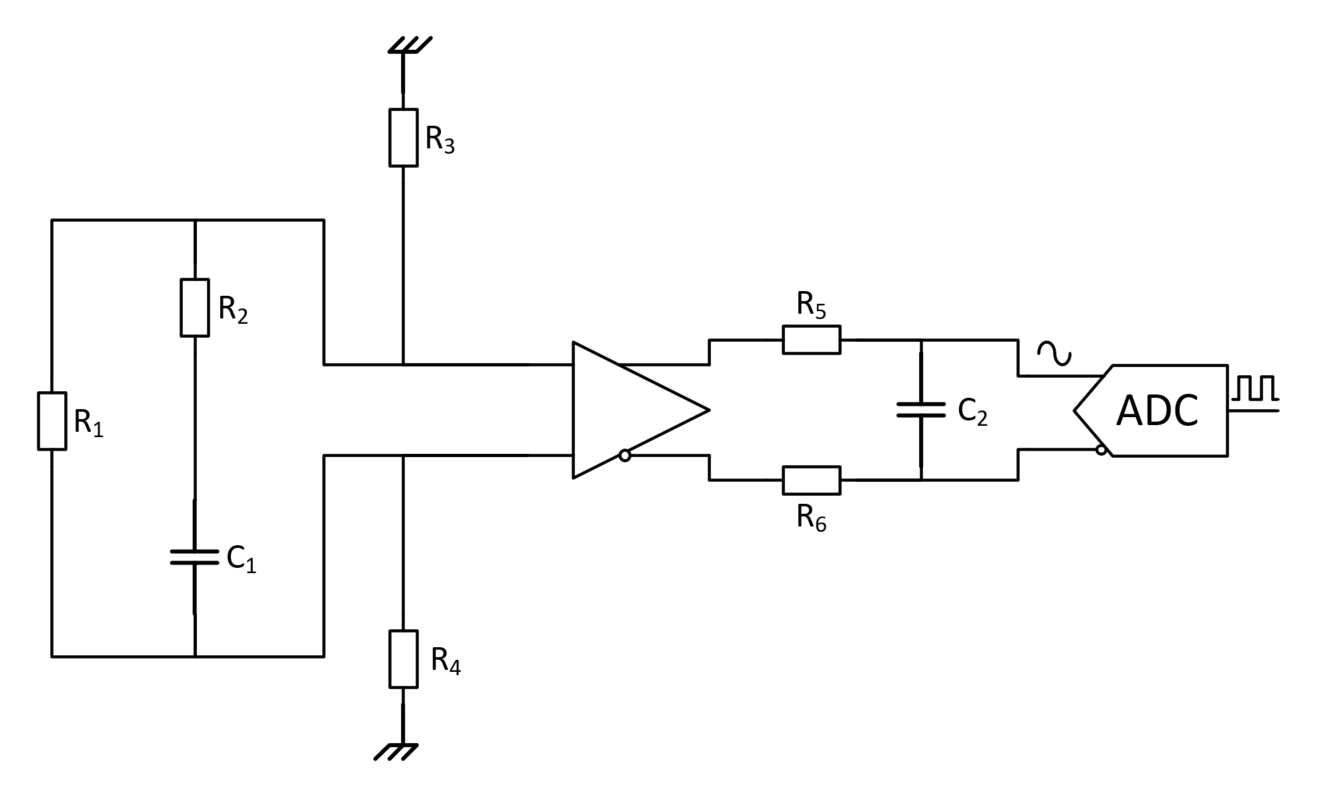

In [276]:
data_filename = 'mod-erro-only' + data_filename_ext

#Température
T = 25  #°C

### Résistances ###
R1 = 100
R2 = 100
R3 = 10e3
R4 = 10e3
R5 = 15
R6 = 15

er1 = thermal_noise(R1, Celsius2Kelvin(T))
er2 = thermal_noise(R2, Celsius2Kelvin(T))
er3 = thermal_noise(R3, Celsius2Kelvin(T))
er4 = thermal_noise(R4, Celsius2Kelvin(T))
er5 = thermal_noise(R5, Celsius2Kelvin(T))
er6 = thermal_noise(R6, Celsius2Kelvin(T))

### Actifs ###
#RHF200
e_rhf_o = 10e-9
#ADC
Vpp = 2
N = 14
#quantization noise
e_adc_q, _, LSB = quantization_noise(Vpp, N, Fs)
#thermal noise
rms_adc_th = 1.25  #LSB rms
BW_adc_th_noise = 150e6 / 2  #Hz
#Input BW
ADC_BW = 650e6
tau_c_ADC = 1 / (2 * np.pi * ADC_BW)
H_ADC = lambda w: 1 / (1 + 1j * tau_c_ADC * w)
#Calcul de la densité spectrale de bruit thermique
e_adc_th_Ny = rms_adc_th * LSB / np.sqrt(BW_adc_th_noise)  #etalage sur Nyquist
Beq_th = np.pi / 2 * ADC_BW
e_adc_th = e_adc_th_Ny * np.sqrt(BW_adc_th_noise / Beq_th)  #étalage sur toute la bande vis à vis repliement

# Gain des différents bruits

In [277]:
### Gain du LNA ###
gain_rhf = 1

### Capacités de filtrage ###
C1 = 15e-12
C2 = 270e-12

### Les gains permettent de ramener les bruits en entrée de l'ADC ###

#Gain de R5 ou R6
H_R56 = lambda w: 1 / (1 + 1j * (R5 + R6) * C2 * w) * H_ADC(w)

# Gain de R1
zequi_1 = lambda w: (R3 + R4) * (1 + 1j * R2 * C1 * w) / (
            1 + 1j * C1 * (R2 + R3 + R4) * w)  # impédance équivalente vue après R1
H_R1 = lambda w: zequi_1(w) / (R1 + zequi_1(w)) * gain_rhf * H_R56(w)

# Gain de R2
zequi_2 = 1 / (1 / R1 + 1 / (R3 + R4))
H_R2 = lambda w: 1j * zequi_2 * C1 * w / (1 + 1j * (zequi_2 + R2) * C1 * w) * gain_rhf * H_R56(w)

# Gain de R3 ou R4
zequi_3 = lambda w: R1 * (1 + 1j * R2 * C1 * w) / (1 + 1j * C1 * (R2 + R1) * w)
H_R34 = lambda w: 1 / (1 + (R3 + R4) / zequi_3(w)) * gain_rhf * H_R56(w)

#Gain RHF200
H_rhf = lambda w: gain_rhf * H_R56(w)



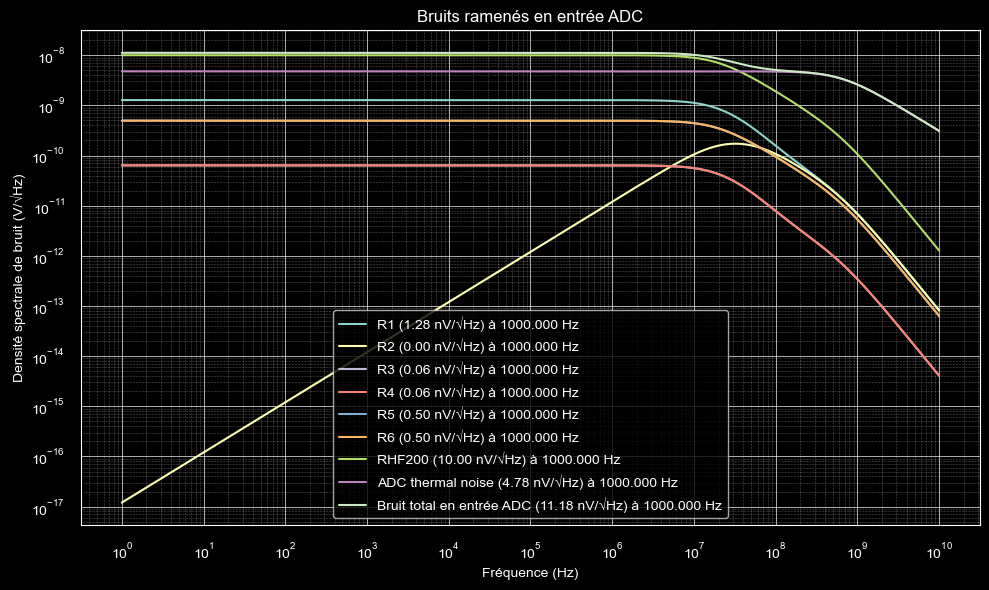

In [278]:
##### Tracé des différentes sources de bruit ####
import matplotlib.pyplot as plt
from matplotlib.ticker import LogLocator

# --- Paramètres ---
f = np.logspace(0, 10, 1000)  # 1 Hz à 10 GHz
w = 2 * np.pi * f

#Vecteurs des bruits ramenés en entrée ADC
er1_out = lambda w: np.abs(H_R1(w)) * er1
er2_out = lambda w: np.abs(H_R2(w)) * er2
er3_out = lambda w: np.abs(H_R34(w)) * er3
er4_out = lambda w: np.abs(H_R34(w)) * er4
er5_out = lambda w: np.abs(H_R56(w)) * er5
er6_out = lambda w: np.abs(H_R56(w)) * er6
erhf_out = lambda w: np.abs(H_rhf(w)) * e_rhf_o
#e_adc_th_out = lambda w: e_adc_th * (np.array(w) <= (np.pi * 2 * BW_adc_th_noise))
e_adc_th_out = lambda w: np.abs(H_ADC(w)) * e_adc_th

e_total_in_adc = lambda w: np.sqrt(
    er1_out(w) ** 2 + er2_out(w) ** 2 + er3_out(w) ** 2 + er4_out(w) ** 2 + er5_out(w) ** 2 + er6_out(
        w) ** 2 + erhf_out(w) ** 2 + e_adc_th_out(w) ** 2)

# --- Tracé ---
freq_print = 1e3  # fréquence pour laquelle on met la mesure du bruit en légende
w_print = 2 * np.pi * freq_print
fig, ax = plt.subplots(figsize=(10, 6))
ax.loglog(f, er1_out(w), label=f"R1 ({er1_out(w_print) * 1e9:.2f} nV/√Hz) à {freq_print:.3f} Hz")
ax.loglog(f, er2_out(w), label=f"R2 ({er2_out(w_print) * 1e9:.2f} nV/√Hz) à {freq_print:.3f} Hz")
ax.loglog(f, er3_out(w), label=f"R3 ({er3_out(w_print) * 1e9:.2f} nV/√Hz) à {freq_print:.3f} Hz")
ax.loglog(f, er4_out(w), label=f"R4 ({er4_out(w_print) * 1e9:.2f} nV/√Hz) à {freq_print:.3f} Hz")
ax.loglog(f, er5_out(w), label=f"R5 ({er5_out(w_print) * 1e9:.2f} nV/√Hz) à {freq_print:.3f} Hz")
ax.loglog(f, er6_out(w), label=f"R6 ({er6_out(w_print) * 1e9:.2f} nV/√Hz) à {freq_print:.3f} Hz")
ax.loglog(f, erhf_out(w), label=f"RHF200 ({erhf_out(w_print) * 1e9:.2f} nV/√Hz) à {freq_print:.3f} Hz")
ax.loglog(f, e_adc_th_out(w),
          label=f"ADC thermal noise ({e_adc_th_out(w_print) * 1e9:.2f} nV/√Hz) à {freq_print:.3f} Hz")
ax.loglog(f, e_total_in_adc(w),
          label=f"Bruit total en entrée ADC ({e_total_in_adc(w_print) * 1e9:.2f} nV/√Hz) à {freq_print:.3f} Hz")

### Mise en forme ###
ax.set_title("Bruits ramenés en entrée ADC")
ax.set_xlabel("Fréquence (Hz)")
ax.set_ylabel("Densité spectrale de bruit (V/√Hz)")

# grille principale
ax.grid(which='major', linestyle='-', linewidth=0.6, alpha=0.8)
# grille secondaire (optionnelle, plus discrète)
ax.grid(which='minor', linestyle=':', linewidth=0.4, alpha=0.6)

# --- FORCER les graduations secondaires (minor ticks) ---
# Major ticks : puissances de 10 (10^n)
ax.xaxis.set_major_locator(LogLocator(base=10.0, numticks=15))
ax.yaxis.set_major_locator(LogLocator(base=10.0, numticks=15))

# Minor ticks : entre 2,3,...,9 * 10^n
# Utiliser subs = np.arange(2,10) (valeurs 2..9). Certains anciens matplotlib
# acceptent subs as list/tuple; ici on passe un ndarray.
ax.xaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10), numticks=100))
ax.yaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10), numticks=100))

# Ajuster l'apparence des ticks
ax.tick_params(which='major', length=8, width=1)
ax.tick_params(which='minor', length=4, width=0.8, color='gray')

ax.legend()
plt.tight_layout()
plt.show()

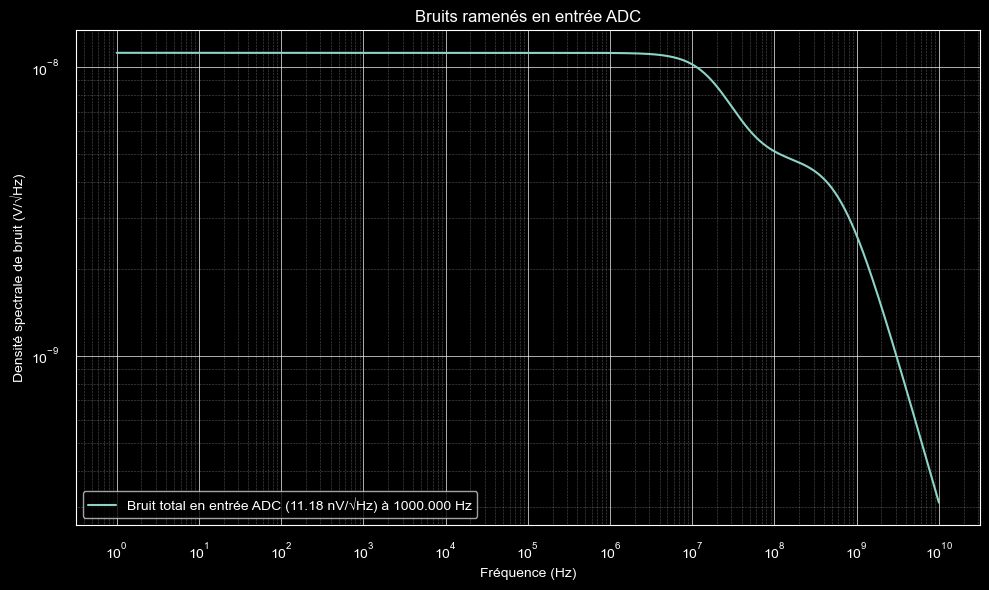

In [279]:
### Tracé du bruit en sortie ###

fig, ax = plt.subplots(figsize=(10, 6))
ax.loglog(f, e_total_in_adc(w),
          label=f"Bruit total en entrée ADC ({e_total_in_adc(w_print) * 1e9:.2f} nV/√Hz) à {freq_print:.3f} Hz")

### Mise en forme ###
ax.set_title("Bruits ramenés en entrée ADC")
ax.set_xlabel("Fréquence (Hz)")
ax.set_ylabel("Densité spectrale de bruit (V/√Hz)")

# grille principale
ax.grid(which='major', linestyle='-', linewidth=0.6, alpha=0.8)
# grille secondaire (optionnelle, plus discrète)
ax.grid(which='minor', linestyle=':', linewidth=0.4, alpha=0.6)

# --- FORCER les graduations secondaires (minor ticks) ---
# Major ticks : puissances de 10 (10^n)
ax.xaxis.set_major_locator(LogLocator(base=10.0, numticks=15))
ax.yaxis.set_major_locator(LogLocator(base=10.0, numticks=15))

# Minor ticks : entre 2,3,...,9 * 10^n
# Utiliser subs = np.arange(2,10) (valeurs 2..9). Certains anciens matplotlib
# acceptent subs as list/tuple; ici on passe un ndarray.
ax.xaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10), numticks=100))
ax.yaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10), numticks=100))

# Ajuster l'apparence des ticks
ax.tick_params(which='major', length=8, width=1)
ax.tick_params(which='minor', length=4, width=0.8, color='gray')

ax.legend()
plt.tight_layout()
plt.show()

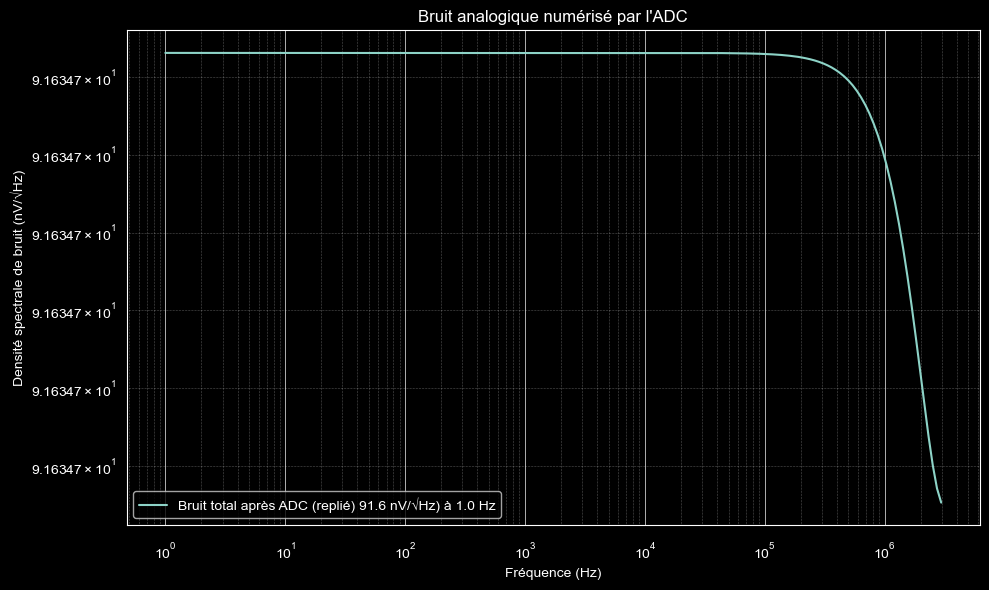

In [280]:
### Bruit replié par échantillonage ###

# ==== PARAMÈTRES ====
fmax = 100e9  # domaine fréquentiel du système analogique (Hz)
N_num = 200  # nombre de points en numérique sur Fs/2

f_num, e_fold = aliasing(e_total_in_adc, fmax, Fs, N_num)

# ==== AFFICHAGE ====
N_print = 0
freq_print = f_num[N_print]
fig, ax = plt.subplots(figsize=(10, 6))
ax.loglog(f_num, e_fold * 1e9,
          label=f"Bruit total après ADC (replié) {e_fold[N_print] * 1e9:.1f} nV/√Hz) à {freq_print:.1f} Hz")
#ax.loglog(f_num, np.ones_like(f_num),label=f"Bruit avant repliement {1}")

### Mise en forme ###
ax.set_title("Bruit analogique numérisé par l'ADC")
ax.set_xlabel("Fréquence (Hz)")
ax.set_ylabel("Densité spectrale de bruit (nV/√Hz)")

# grille principale
ax.grid(which='major', linestyle='-', linewidth=0.6, alpha=0.8)
# grille secondaire (optionnelle, plus discrète)
ax.grid(which='minor', linestyle=':', linewidth=0.4, alpha=0.6)

# --- FORCER les graduations secondaires (minor ticks) ---
# Major ticks : puissances de 10 (10^n)
ax.xaxis.set_major_locator(LogLocator(base=10.0, numticks=15))
ax.yaxis.set_major_locator(LogLocator(base=10.0, numticks=15))

# Minor ticks : entre 2,3,...,9 * 10^n
# Utiliser subs = np.arange(2,10) (valeurs 2..9). Certains anciens matplotlib
# acceptent subs as list/tuple; ici on passe un ndarray.
ax.xaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10), numticks=100))
ax.yaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10), numticks=100))

# Ajuster l'apparence des ticks
ax.tick_params(which='major', length=8, width=1)
ax.tick_params(which='minor', length=4, width=0.8, color='gray')

ax.legend()
plt.tight_layout()
plt.show()

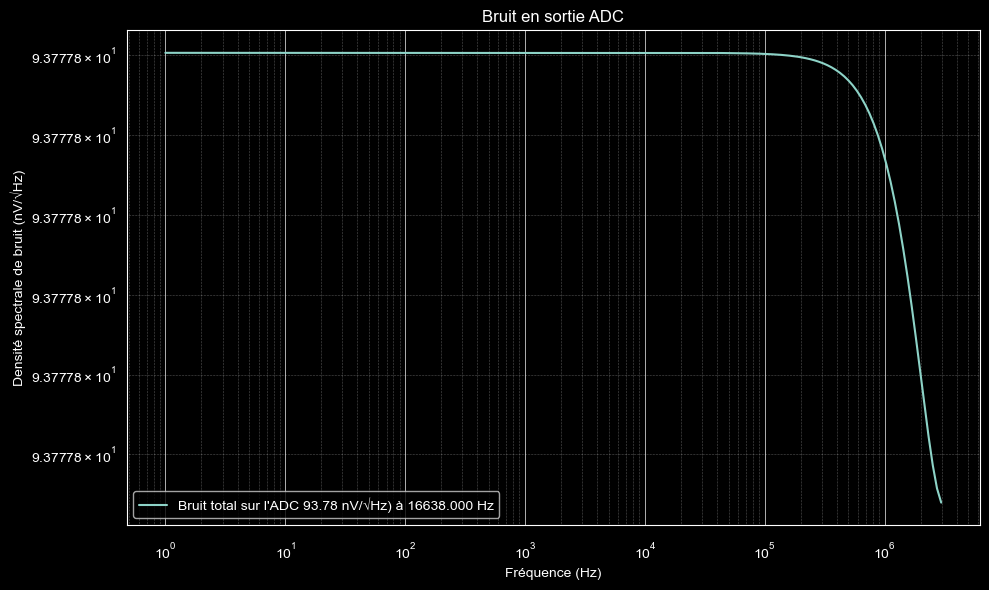

In [281]:
# ajout du bruit de quantification

e_total = np.sqrt(np.ones_like(f_num) * e_adc_q ** 2 + e_fold ** 2)

# ==== AFFICHAGE ====
N_print = 100
freq_print = f_num[N_print]
fig, ax = plt.subplots(figsize=(10, 6))
ax.loglog(f_num, e_total * 1e9,
          label=f"Bruit total sur l'ADC {e_total[N_print] * 1e9:.2f} nV/√Hz) à {freq_print:.3f} Hz")

### Mise en forme ###
ax.set_title("Bruit en sortie ADC")
ax.set_xlabel("Fréquence (Hz)")
ax.set_ylabel("Densité spectrale de bruit (nV/√Hz)")

# grille principale
ax.grid(which='major', linestyle='-', linewidth=0.6, alpha=0.8)
# grille secondaire (optionnelle, plus discrète)
ax.grid(which='minor', linestyle=':', linewidth=0.4, alpha=0.6)

# --- FORCER les graduations secondaires (minor ticks) ---
# Major ticks : puissances de 10 (10^n)
ax.xaxis.set_major_locator(LogLocator(base=10.0, numticks=15))
ax.yaxis.set_major_locator(LogLocator(base=10.0, numticks=15))

# Minor ticks : entre 2,3,...,9 * 10^n
ax.xaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10), numticks=100))
ax.yaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10), numticks=100))

# Ajuster l'apparence des ticks
ax.tick_params(which='major', length=8, width=1)
ax.tick_params(which='minor', length=4, width=0.8, color='gray')

ax.legend()
plt.tight_layout()
plt.show()


In [282]:
export_2vectors_to_file(f_num, e_total, data_filename)


# Bruit de la chaîne DAC FB rebouclé sur ADC

## 1. Awaxe

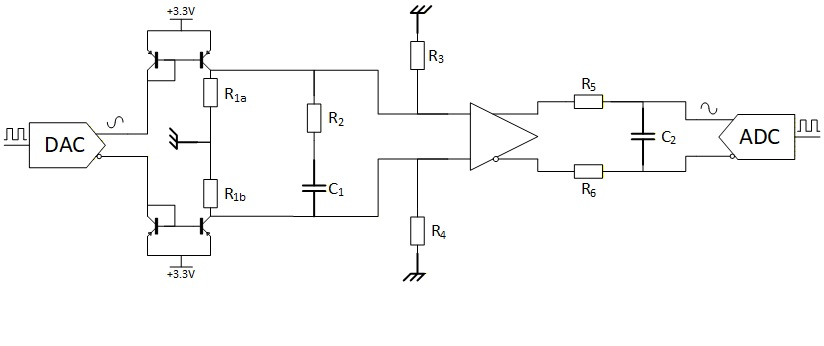

In [283]:
data_filename = 'mod-erro-fdbk-awaxe' + data_filename_ext

#Température
T = 25  #°C

### Résistances ###
R1a = 50
R1b = 50
R2 = 100
R3 = 10e3
R4 = 10e3
R5 = 15
R6 = 15

er1a = thermal_noise(R1a, Celsius2Kelvin(T))
er1b = thermal_noise(R1b, Celsius2Kelvin(T))
er2 = thermal_noise(R2, Celsius2Kelvin(T))
er3 = thermal_noise(R3, Celsius2Kelvin(T))
er4 = thermal_noise(R4, Celsius2Kelvin(T))
er5 = thermal_noise(R5, Celsius2Kelvin(T))
er6 = thermal_noise(R6, Celsius2Kelvin(T))

### Actifs ###
#RHF200
e_rhf_o = 10e-9
#DAC
IDAC = 20e-3
in_DAC = shot_noise(IDAC)
#miroir de courant
in_mirror = np.sqrt(2) * in_DAC
#ADC
Vpp = 2
N = 14
#quantization noise
e_adc_q, _, LSB = quantization_noise(Vpp, N, Fs)
#thermal noise
rms_adc_th = 1.25  #LSB rms
BW_adc_th_noise = 150e6 / 2  #Hz
#Input BW
ADC_BW = 650e6
tau_c_ADC = 1 / (2 * np.pi * ADC_BW)
H_ADC = lambda w: 1 / (1 + 1j * tau_c_ADC * w)
#Calcul de la densité spectrale de bruit thermique
e_adc_th_Ny = rms_adc_th * LSB / np.sqrt(BW_adc_th_noise)  #etalage sur Nyquist
Beq_th = np.pi / 2 * ADC_BW
e_adc_th = e_adc_th_Ny * np.sqrt(BW_adc_th_noise / Beq_th)  #étalage sur toute la bande vis à vis repliement

### Gain des bruits

In [284]:
### Gain du RHF200 ###
gain_rhf = 1

### Capacités de filtrage ###
C1 = 15e-12
C2 = 270e-12

### Les gains permettent de ramener les bruits en entrée de l'ADC ###

#Gain de R5 ou R6
H_R56 = lambda w: 1 / (1 + 1j * (R5 + R6) * C2 * w) * H_ADC(w)

# Gain de R1
zequi_1 = lambda w: (R3 + R4) * (1 + 1j * R2 * C1 * w) / (
            1 + 1j * C1 * (R2 + R3 + R4) * w)  # impédance équivalente vue après R1
H_R1 = lambda w: zequi_1(w) / (R1a + R1b + zequi_1(w)) * gain_rhf * H_R56(w)

# Gain de R2
zequi_2 = 1 / (1 / (R1a + R1b) + 1 / (R3 + R4))
H_R2 = lambda w: 1j * zequi_2 * C1 * w / (1 + 1j * (zequi_2 + R2) * C1 * w) * gain_rhf * H_R56(w)

# Gain de R3 ou R4
zequi_3 = lambda w: (R1a + R1b) * (1 + 1j * R2 * C1 * w) / (1 + 1j * C1 * (R2 + R1a + R1b) * w)
H_R34 = lambda w: 1 / (1 + (R3 + R4) / zequi_3(w)) * gain_rhf * H_R56(w)

#Gain RHF200
H_rhf = lambda w: gain_rhf * H_R56(w)

#Gain Miroir de courant
H_current_mirror = lambda w: (R1a) * H_R1(w)  #Vrai seulement si R1a = R1b

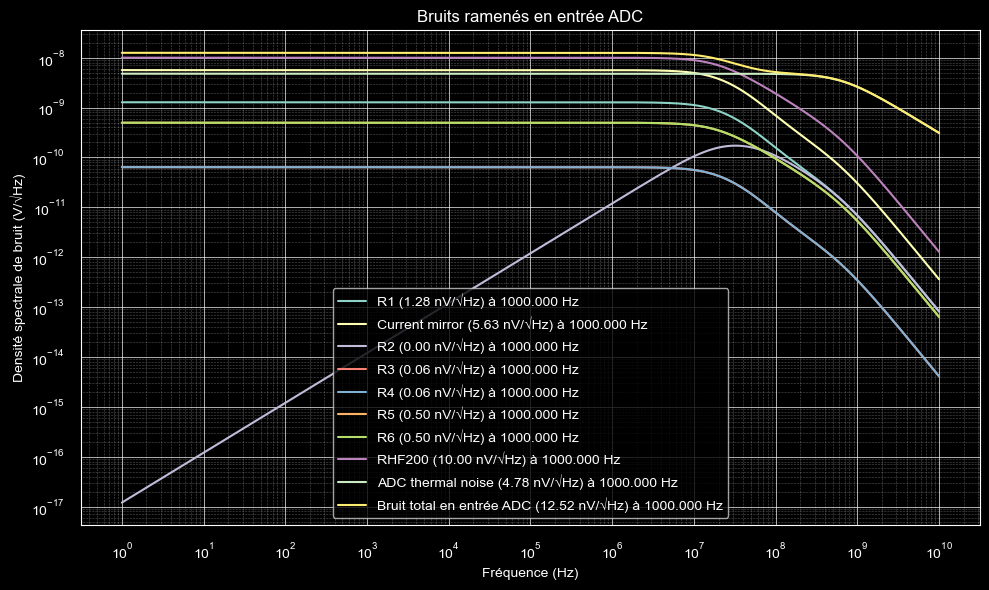

In [285]:
##### Tracé des différentes sources de bruit ####
import matplotlib.pyplot as plt
from matplotlib.ticker import LogLocator

# --- Paramètres ---
f = np.logspace(0, 10, 1000)  # 1 Hz à 10 GHz
w = 2 * np.pi * f

#Vecteurs des bruits ramenés en entrée ADC
er1_out = lambda w: np.abs(H_R1(w)) * np.sqrt(er1a ** 2 + er1b ** 2)
e_miror_out = lambda w: np.abs(H_current_mirror(w)) * in_mirror
er2_out = lambda w: np.abs(H_R2(w)) * er2
er3_out = lambda w: np.abs(H_R34(w)) * er3
er4_out = lambda w: np.abs(H_R34(w)) * er4
er5_out = lambda w: np.abs(H_R56(w)) * er5
er6_out = lambda w: np.abs(H_R56(w)) * er6
erhf_out = lambda w: np.abs(H_rhf(w)) * e_rhf_o
#e_adc_th_out = lambda w: e_adc_th * (np.array(w) <= (np.pi * 2 * BW_adc_th_noise))
e_adc_th_out = lambda w: np.abs(H_ADC(w)) * e_adc_th

e_total_in_adc = lambda w: np.sqrt(
    er1_out(w) ** 2 + er2_out(w) ** 2 + er3_out(w) ** 2 + er4_out(w) ** 2 + er5_out(w) ** 2 + er6_out(
        w) ** 2 + erhf_out(w) ** 2 + e_adc_th_out(w) ** 2 + e_miror_out(w) ** 2)

# --- Tracé ---
freq_print = 1e3  # fréquence pour laquelle on met la mesure du bruit en légende
w_print = 2 * np.pi * freq_print
fig, ax = plt.subplots(figsize=(10, 6))
ax.loglog(f, er1_out(w), label=f"R1 ({er1_out(w_print) * 1e9:.2f} nV/√Hz) à {freq_print:.3f} Hz")
ax.loglog(f, e_miror_out(w), label=f"Current mirror ({e_miror_out(w_print) * 1e9:.2f} nV/√Hz) à {freq_print:.3f} Hz")
ax.loglog(f, er2_out(w), label=f"R2 ({er2_out(w_print) * 1e9:.2f} nV/√Hz) à {freq_print:.3f} Hz")
ax.loglog(f, er3_out(w), label=f"R3 ({er3_out(w_print) * 1e9:.2f} nV/√Hz) à {freq_print:.3f} Hz")
ax.loglog(f, er4_out(w), label=f"R4 ({er4_out(w_print) * 1e9:.2f} nV/√Hz) à {freq_print:.3f} Hz")
ax.loglog(f, er5_out(w), label=f"R5 ({er5_out(w_print) * 1e9:.2f} nV/√Hz) à {freq_print:.3f} Hz")
ax.loglog(f, er6_out(w), label=f"R6 ({er6_out(w_print) * 1e9:.2f} nV/√Hz) à {freq_print:.3f} Hz")
ax.loglog(f, erhf_out(w), label=f"RHF200 ({erhf_out(w_print) * 1e9:.2f} nV/√Hz) à {freq_print:.3f} Hz")
ax.loglog(f, e_adc_th_out(w),
          label=f"ADC thermal noise ({e_adc_th_out(w_print) * 1e9:.2f} nV/√Hz) à {freq_print:.3f} Hz")
ax.loglog(f, e_total_in_adc(w),
          label=f"Bruit total en entrée ADC ({e_total_in_adc(w_print) * 1e9:.2f} nV/√Hz) à {freq_print:.3f} Hz")

### Mise en forme ###
ax.set_title("Bruits ramenés en entrée ADC")
ax.set_xlabel("Fréquence (Hz)")
ax.set_ylabel("Densité spectrale de bruit (V/√Hz)")

# grille principale
ax.grid(which='major', linestyle='-', linewidth=0.6, alpha=0.8)
# grille secondaire (optionnelle, plus discrète)
ax.grid(which='minor', linestyle=':', linewidth=0.4, alpha=0.6)

# --- FORCER les graduations secondaires (minor ticks) ---
# Major ticks : puissances de 10 (10^n)
ax.xaxis.set_major_locator(LogLocator(base=10.0, numticks=15))
ax.yaxis.set_major_locator(LogLocator(base=10.0, numticks=15))

# Minor ticks : entre 2,3,...,9 * 10^n
# Utiliser subs = np.arange(2,10) (valeurs 2..9). Certains anciens matplotlib
# acceptent subs as list/tuple; ici on passe un ndarray.
ax.xaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10), numticks=100))
ax.yaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10), numticks=100))

# Ajuster l'apparence des ticks
ax.tick_params(which='major', length=8, width=1)
ax.tick_params(which='minor', length=4, width=0.8, color='gray')

ax.legend()
plt.tight_layout()
plt.show()

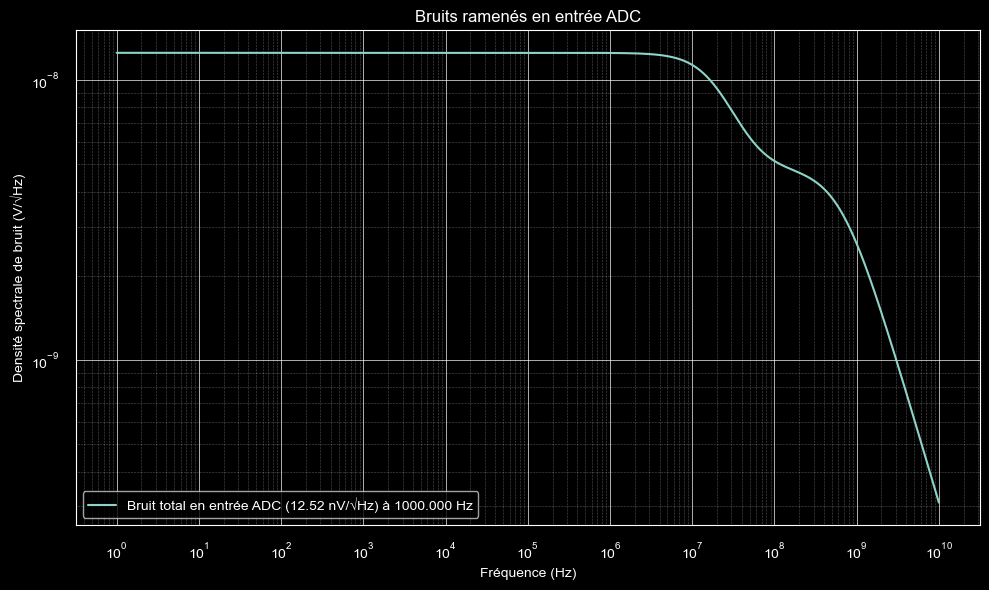

In [286]:
### Tracé du bruit en sortie ###

fig, ax = plt.subplots(figsize=(10, 6))
ax.loglog(f, e_total_in_adc(w),
          label=f"Bruit total en entrée ADC ({e_total_in_adc(w_print) * 1e9:.2f} nV/√Hz) à {freq_print:.3f} Hz")

### Mise en forme ###
ax.set_title("Bruits ramenés en entrée ADC")
ax.set_xlabel("Fréquence (Hz)")
ax.set_ylabel("Densité spectrale de bruit (V/√Hz)")

# grille principale
ax.grid(which='major', linestyle='-', linewidth=0.6, alpha=0.8)
# grille secondaire (optionnelle, plus discrète)
ax.grid(which='minor', linestyle=':', linewidth=0.4, alpha=0.6)

# --- FORCER les graduations secondaires (minor ticks) ---
# Major ticks : puissances de 10 (10^n)
ax.xaxis.set_major_locator(LogLocator(base=10.0, numticks=15))
ax.yaxis.set_major_locator(LogLocator(base=10.0, numticks=15))

# Minor ticks : entre 2,3,...,9 * 10^n
# Utiliser subs = np.arange(2,10) (valeurs 2..9). Certains anciens matplotlib
# acceptent subs as list/tuple; ici on passe un ndarray.
ax.xaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10), numticks=100))
ax.yaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10), numticks=100))

# Ajuster l'apparence des ticks
ax.tick_params(which='major', length=8, width=1)
ax.tick_params(which='minor', length=4, width=0.8, color='gray')

ax.legend()
plt.tight_layout()
plt.show()

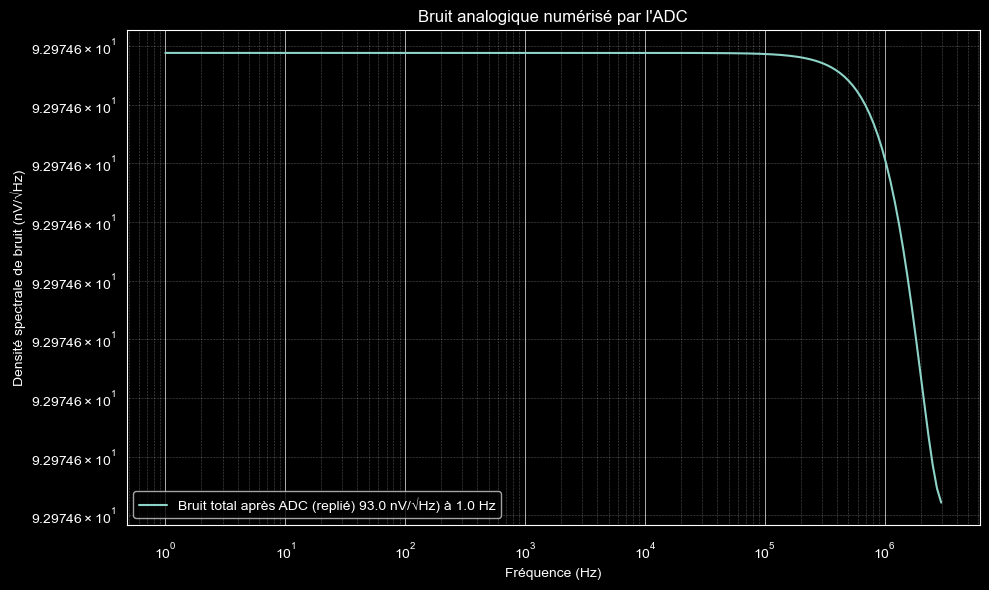

In [287]:
### Bruit replié par échantillonage ###

# ==== PARAMÈTRES ====
fmax = 100e9  # domaine fréquentiel du système analogique (Hz)
N_num = 200  # nombre de points en numérique sur Fs/2

f_num, e_fold = aliasing(e_total_in_adc, fmax, Fs, N_num)

# ==== AFFICHAGE ====
N_print = 0
freq_print = f_num[N_print]
fig, ax = plt.subplots(figsize=(10, 6))
ax.loglog(f_num, e_fold * 1e9,
          label=f"Bruit total après ADC (replié) {e_fold[N_print] * 1e9:.1f} nV/√Hz) à {freq_print:.1f} Hz")
#ax.loglog(f_num, np.ones_like(f_num),label=f"Bruit avant repliement {1}")

### Mise en forme ###
ax.set_title("Bruit analogique numérisé par l'ADC")
ax.set_xlabel("Fréquence (Hz)")
ax.set_ylabel("Densité spectrale de bruit (nV/√Hz)")

# grille principale
ax.grid(which='major', linestyle='-', linewidth=0.6, alpha=0.8)
# grille secondaire (optionnelle, plus discrète)
ax.grid(which='minor', linestyle=':', linewidth=0.4, alpha=0.6)

# --- FORCER les graduations secondaires (minor ticks) ---
# Major ticks : puissances de 10 (10^n)
ax.xaxis.set_major_locator(LogLocator(base=10.0, numticks=15))
ax.yaxis.set_major_locator(LogLocator(base=10.0, numticks=15))

# Minor ticks : entre 2,3,...,9 * 10^n
# Utiliser subs = np.arange(2,10) (valeurs 2..9). Certains anciens matplotlib
# acceptent subs as list/tuple; ici on passe un ndarray.
ax.xaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10), numticks=100))
ax.yaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10), numticks=100))

# Ajuster l'apparence des ticks
ax.tick_params(which='major', length=8, width=1)
ax.tick_params(which='minor', length=4, width=0.8, color='gray')

ax.legend()
plt.tight_layout()
plt.show()

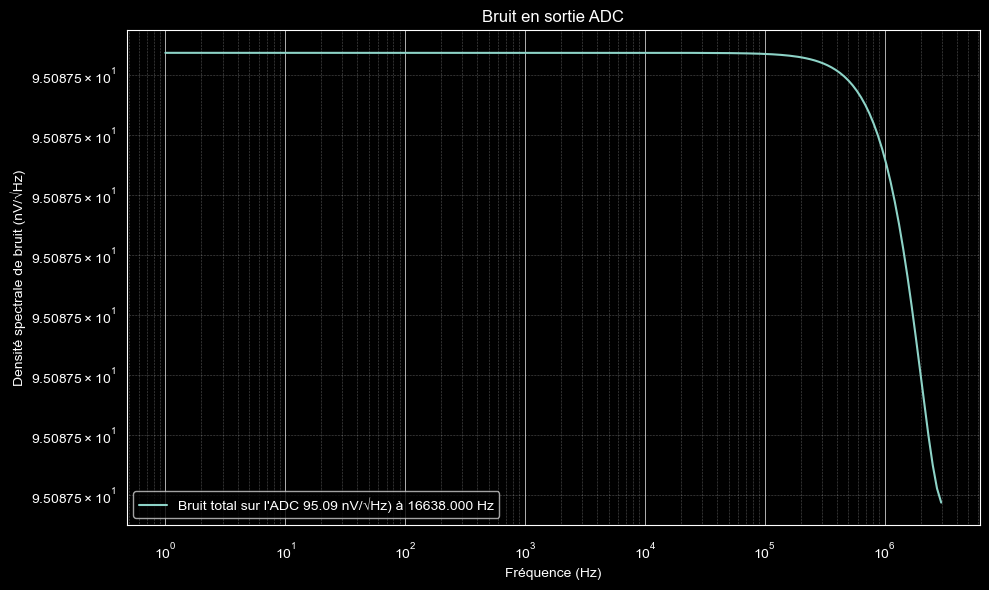

In [288]:
# ajout du bruit de quantification

e_total = np.sqrt(np.ones_like(f_num) * e_adc_q ** 2 + e_fold ** 2)

# ==== AFFICHAGE ====
N_print = 100
freq_print = f_num[N_print]
fig, ax = plt.subplots(figsize=(10, 6))
ax.loglog(f_num, e_total * 1e9,
          label=f"Bruit total sur l'ADC {e_total[N_print] * 1e9:.2f} nV/√Hz) à {freq_print:.3f} Hz")

### Mise en forme ###
ax.set_title("Bruit en sortie ADC")
ax.set_xlabel("Fréquence (Hz)")
ax.set_ylabel("Densité spectrale de bruit (nV/√Hz)")

# grille principale
ax.grid(which='major', linestyle='-', linewidth=0.6, alpha=0.8)
# grille secondaire (optionnelle, plus discrète)
ax.grid(which='minor', linestyle=':', linewidth=0.4, alpha=0.6)

# --- FORCER les graduations secondaires (minor ticks) ---
# Major ticks : puissances de 10 (10^n)
ax.xaxis.set_major_locator(LogLocator(base=10.0, numticks=15))
ax.yaxis.set_major_locator(LogLocator(base=10.0, numticks=15))

# Minor ticks : entre 2,3,...,9 * 10^n
ax.xaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10), numticks=100))
ax.yaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10), numticks=100))

# Ajuster l'apparence des ticks
ax.tick_params(which='major', length=8, width=1)
ax.tick_params(which='minor', length=4, width=0.8, color='gray')

ax.legend()
plt.tight_layout()
plt.show()


In [289]:
export_2vectors_to_file(f_num, e_total, data_filename)


## 2. RHF200

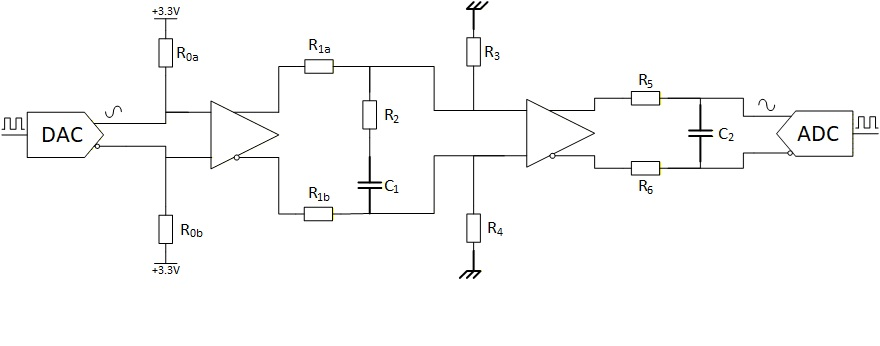

In [290]:
data_filename = 'erro-fdbk-rhf200' + data_filename_ext

#Température
T = 25  #°C

### Résistances ###
R0a = 50
R0b = 50
R1a = 50
R1b = 50
R2 = 100
R3 = 10e3
R4 = 10e3
R5 = 15
R6 = 15

er0a = thermal_noise(R0a, Celsius2Kelvin(T))
er0b = thermal_noise(R0b, Celsius2Kelvin(T))
er1a = thermal_noise(R1a, Celsius2Kelvin(T))
er1b = thermal_noise(R1b, Celsius2Kelvin(T))
er2 = thermal_noise(R2, Celsius2Kelvin(T))
er3 = thermal_noise(R3, Celsius2Kelvin(T))
er4 = thermal_noise(R4, Celsius2Kelvin(T))
er5 = thermal_noise(R5, Celsius2Kelvin(T))
er6 = thermal_noise(R6, Celsius2Kelvin(T))

### Actifs ###
#RHF200
e_rhf_o = 10e-9
#DAC
IDAC = 20e-3
in_DAC = shot_noise(IDAC)
#ADC
Vpp = 2
N = 14
#quantization noise
e_adc_q, _, LSB = quantization_noise(Vpp, N, Fs)
#thermal noise
rms_adc_th = 1.25  #LSB rms
BW_adc_th_noise = 150e6 / 2  #Hz
#Input BW
ADC_BW = 650e6
tau_c_ADC = 1 / (2 * np.pi * ADC_BW)
H_ADC = lambda w: 1 / (1 + 1j * tau_c_ADC * w)
#Calcul de la densité spectrale de bruit thermique
e_adc_th_Ny = rms_adc_th * LSB / np.sqrt(BW_adc_th_noise)  #etalage sur Nyquist
Beq_th = np.pi / 2 * ADC_BW
e_adc_th = e_adc_th_Ny * np.sqrt(BW_adc_th_noise / Beq_th)  #étalage sur toute la bande vis à vis repliement

# Gain des bruits

In [291]:
### Gain du RHF200 ###
gain_rhf_adc = 1
gain_rhf_dac = 1

### Capacités de filtrage ###
C1 = 15e-12
C2 = 270e-12

### Les gains permettent de ramener les bruits en entrée de l'ADC ###

#Gain de R5 ou R6
H_R56 = lambda w: 1 / (1 + 1j * (R5 + R6) * C2 * w) * H_ADC(w)

# Gain de R1
zequi_1 = lambda w: (R3 + R4) * (1 + 1j * R2 * C1 * w) / (
            1 + 1j * C1 * (R2 + R3 + R4) * w)  # impédance équivalente vue après R1
H_R1 = lambda w: zequi_1(w) / (R1a + R1b + zequi_1(w)) * gain_rhf_adc * H_R56(w)

# Gain de R2
zequi_2 = 1 / (1 / (R1a + R1b) + 1 / (R3 + R4))
H_R2 = lambda w: 1j * zequi_2 * C1 * w / (1 + 1j * (zequi_2 + R2) * C1 * w) * gain_rhf_adc * H_R56(w)

# Gain de R3 ou R4
zequi_3 = lambda w: (R1a + R1b) * (1 + 1j * R2 * C1 * w) / (1 + 1j * C1 * (R2 + R1a + R1b) * w)
H_R34 = lambda w: 1 / (1 + (R3 + R4) / zequi_3(w)) * gain_rhf_adc * H_R56(w)

#Gain RHF200 ADC
H_rhf_adc = lambda w: H_R56(w)

#Gain RHF200 DAC
H_rhf_dac = lambda w: H_R1(w)

#Gain R0
H_R0 = lambda w: gain_rhf_dac * H_rhf_dac(w)

#Gain DAC
H_dac = lambda w: R0a * gain_rhf_dac * H_rhf_dac(w)

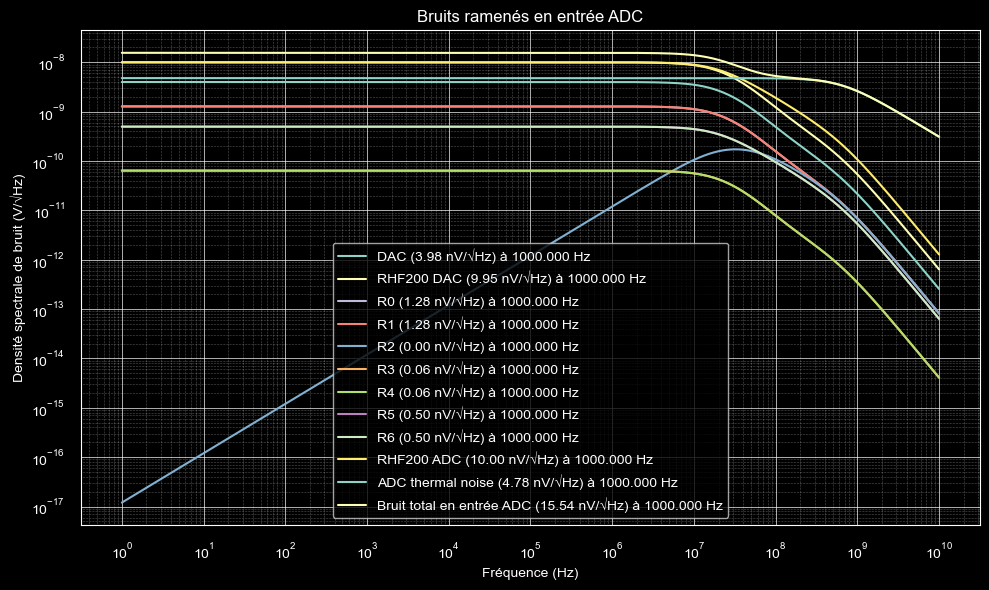

In [292]:
##### Tracé des différentes sources de bruit ####
import matplotlib.pyplot as plt
from matplotlib.ticker import LogLocator

# --- Paramètres ---
f = np.logspace(0, 10, 1000)  # 1 Hz à 10 GHz
w = 2 * np.pi * f

#Vecteurs des bruits ramenés en entrée ADC
e_dac_out = lambda w: np.abs(H_dac(w)) * in_DAC
erhf_dac_out = lambda w: np.abs(H_rhf_dac(w)) * e_rhf_o
er0_out = lambda w: np.abs(H_R0(w)) * np.sqrt(er0a ** 2 + er0b ** 2)
er1_out = lambda w: np.abs(H_R1(w)) * np.sqrt(er1a ** 2 + er1b ** 2)
er2_out = lambda w: np.abs(H_R2(w)) * er2
er3_out = lambda w: np.abs(H_R34(w)) * er3
er4_out = lambda w: np.abs(H_R34(w)) * er4
er5_out = lambda w: np.abs(H_R56(w)) * er5
er6_out = lambda w: np.abs(H_R56(w)) * er6
erhf_adc_out = lambda w: np.abs(H_rhf_adc(w)) * e_rhf_o
#e_adc_th_out = lambda w: e_adc_th * (np.array(w) <= (np.pi * 2 * BW_adc_th_noise))
e_adc_th_out = lambda w: np.abs(H_ADC(w)) * e_adc_th

e_total_in_adc = lambda w: np.sqrt(
    e_dac_out(w) ** 2 + erhf_dac_out(w) ** 2 + er0_out(w) ** 2 + er1_out(w) ** 2 + er2_out(w) ** 2 + er3_out(
        w) ** 2 + er4_out(w) ** 2 + er5_out(w) ** 2 + er6_out(w) ** 2 + erhf_adc_out(w) ** 2 + e_adc_th_out(w) ** 2)

# --- Tracé ---
freq_print = 1e3  # fréquence pour laquelle on met la mesure du bruit en légende
w_print = 2 * np.pi * freq_print
fig, ax = plt.subplots(figsize=(10, 6))
ax.loglog(f, e_dac_out(w), label=f"DAC ({e_dac_out(w_print) * 1e9:.2f} nV/√Hz) à {freq_print:.3f} Hz")
ax.loglog(f, erhf_dac_out(w), label=f"RHF200 DAC ({erhf_dac_out(w_print) * 1e9:.2f} nV/√Hz) à {freq_print:.3f} Hz")
ax.loglog(f, er0_out(w), label=f"R0 ({er1_out(w_print) * 1e9:.2f} nV/√Hz) à {freq_print:.3f} Hz")
ax.loglog(f, er1_out(w), label=f"R1 ({er1_out(w_print) * 1e9:.2f} nV/√Hz) à {freq_print:.3f} Hz")
ax.loglog(f, er2_out(w), label=f"R2 ({er2_out(w_print) * 1e9:.2f} nV/√Hz) à {freq_print:.3f} Hz")
ax.loglog(f, er3_out(w), label=f"R3 ({er3_out(w_print) * 1e9:.2f} nV/√Hz) à {freq_print:.3f} Hz")
ax.loglog(f, er4_out(w), label=f"R4 ({er4_out(w_print) * 1e9:.2f} nV/√Hz) à {freq_print:.3f} Hz")
ax.loglog(f, er5_out(w), label=f"R5 ({er5_out(w_print) * 1e9:.2f} nV/√Hz) à {freq_print:.3f} Hz")
ax.loglog(f, er6_out(w), label=f"R6 ({er6_out(w_print) * 1e9:.2f} nV/√Hz) à {freq_print:.3f} Hz")
ax.loglog(f, erhf_adc_out(w), label=f"RHF200 ADC ({erhf_adc_out(w_print) * 1e9:.2f} nV/√Hz) à {freq_print:.3f} Hz")
ax.loglog(f, e_adc_th_out(w),
          label=f"ADC thermal noise ({e_adc_th_out(w_print) * 1e9:.2f} nV/√Hz) à {freq_print:.3f} Hz")
ax.loglog(f, e_total_in_adc(w),
          label=f"Bruit total en entrée ADC ({e_total_in_adc(w_print) * 1e9:.2f} nV/√Hz) à {freq_print:.3f} Hz")

### Mise en forme ###
ax.set_title("Bruits ramenés en entrée ADC")
ax.set_xlabel("Fréquence (Hz)")
ax.set_ylabel("Densité spectrale de bruit (V/√Hz)")

# grille principale
ax.grid(which='major', linestyle='-', linewidth=0.6, alpha=0.8)
# grille secondaire (optionnelle, plus discrète)
ax.grid(which='minor', linestyle=':', linewidth=0.4, alpha=0.6)

# --- FORCER les graduations secondaires (minor ticks) ---
# Major ticks : puissances de 10 (10^n)
ax.xaxis.set_major_locator(LogLocator(base=10.0, numticks=15))
ax.yaxis.set_major_locator(LogLocator(base=10.0, numticks=15))

# Minor ticks : entre 2,3,...,9 * 10^n
# Utiliser subs = np.arange(2,10) (valeurs 2..9). Certains anciens matplotlib
# acceptent subs as list/tuple; ici on passe un ndarray.
ax.xaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10), numticks=100))
ax.yaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10), numticks=100))

# Ajuster l'apparence des ticks
ax.tick_params(which='major', length=8, width=1)
ax.tick_params(which='minor', length=4, width=0.8, color='gray')

ax.legend()
plt.tight_layout()
plt.show()

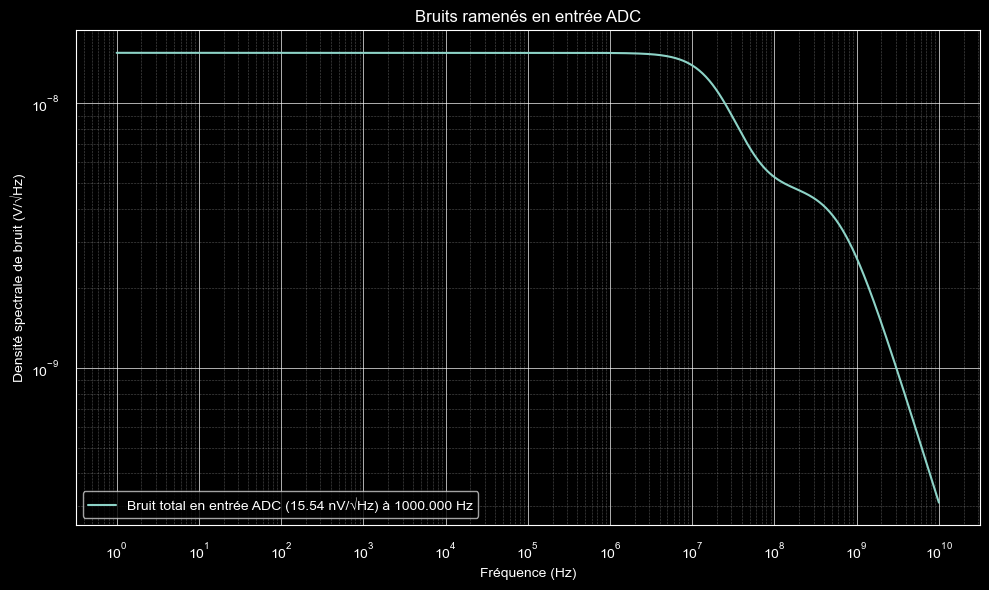

In [293]:
### Tracé du bruit en sortie ###

fig, ax = plt.subplots(figsize=(10, 6))
ax.loglog(f, e_total_in_adc(w),
          label=f"Bruit total en entrée ADC ({e_total_in_adc(w_print) * 1e9:.2f} nV/√Hz) à {freq_print:.3f} Hz")

### Mise en forme ###
ax.set_title("Bruits ramenés en entrée ADC")
ax.set_xlabel("Fréquence (Hz)")
ax.set_ylabel("Densité spectrale de bruit (V/√Hz)")

# grille principale
ax.grid(which='major', linestyle='-', linewidth=0.6, alpha=0.8)
# grille secondaire (optionnelle, plus discrète)
ax.grid(which='minor', linestyle=':', linewidth=0.4, alpha=0.6)

# --- FORCER les graduations secondaires (minor ticks) ---
# Major ticks : puissances de 10 (10^n)
ax.xaxis.set_major_locator(LogLocator(base=10.0, numticks=15))
ax.yaxis.set_major_locator(LogLocator(base=10.0, numticks=15))

# Minor ticks : entre 2,3,...,9 * 10^n
# Utiliser subs = np.arange(2,10) (valeurs 2..9). Certains anciens matplotlib
# acceptent subs as list/tuple; ici on passe un ndarray.
ax.xaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10), numticks=100))
ax.yaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10), numticks=100))

# Ajuster l'apparence des ticks
ax.tick_params(which='major', length=8, width=1)
ax.tick_params(which='minor', length=4, width=0.8, color='gray')

ax.legend()
plt.tight_layout()
plt.show()

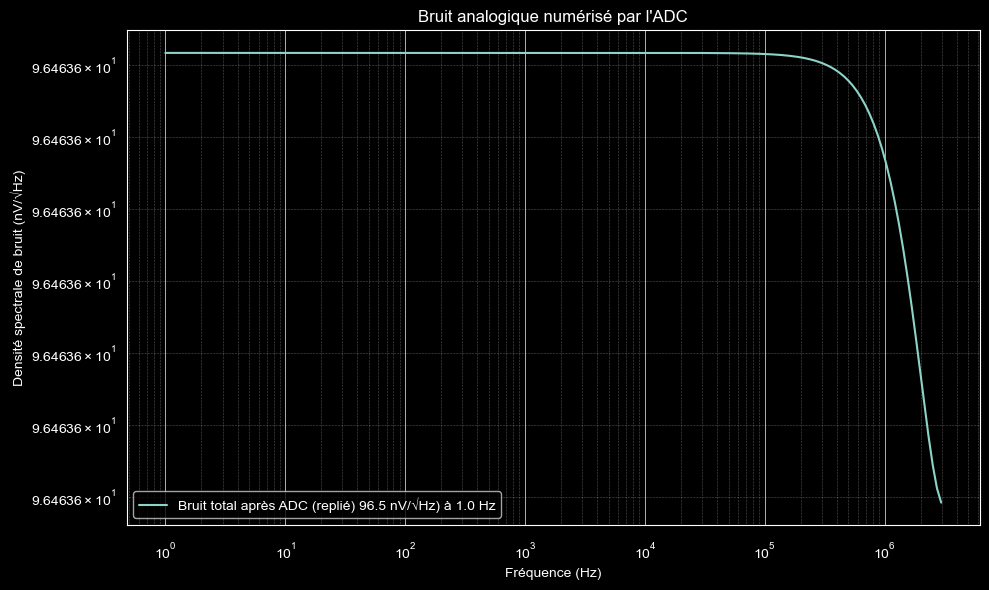

In [294]:
### Bruit replié par échantillonage ###

# ==== PARAMÈTRES ====
fmax = 100e9  # domaine fréquentiel du système analogique (Hz)
N_num = 200  # nombre de points en numérique sur Fs/2

f_num, e_fold = aliasing(e_total_in_adc, fmax, Fs, N_num)

# ==== AFFICHAGE ====
N_print = 0
freq_print = f_num[N_print]
fig, ax = plt.subplots(figsize=(10, 6))
ax.loglog(f_num, e_fold * 1e9,
          label=f"Bruit total après ADC (replié) {e_fold[N_print] * 1e9:.1f} nV/√Hz) à {freq_print:.1f} Hz")
#ax.loglog(f_num, np.ones_like(f_num),label=f"Bruit avant repliement {1}")

### Mise en forme ###
ax.set_title("Bruit analogique numérisé par l'ADC")
ax.set_xlabel("Fréquence (Hz)")
ax.set_ylabel("Densité spectrale de bruit (nV/√Hz)")

# grille principale
ax.grid(which='major', linestyle='-', linewidth=0.6, alpha=0.8)
# grille secondaire (optionnelle, plus discrète)
ax.grid(which='minor', linestyle=':', linewidth=0.4, alpha=0.6)

# --- FORCER les graduations secondaires (minor ticks) ---
# Major ticks : puissances de 10 (10^n)
ax.xaxis.set_major_locator(LogLocator(base=10.0, numticks=15))
ax.yaxis.set_major_locator(LogLocator(base=10.0, numticks=15))

# Minor ticks : entre 2,3,...,9 * 10^n
# Utiliser subs = np.arange(2,10) (valeurs 2..9). Certains anciens matplotlib
# acceptent subs as list/tuple; ici on passe un ndarray.
ax.xaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10), numticks=100))
ax.yaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10), numticks=100))

# Ajuster l'apparence des ticks
ax.tick_params(which='major', length=8, width=1)
ax.tick_params(which='minor', length=4, width=0.8, color='gray')

ax.legend()
plt.tight_layout()
plt.show()

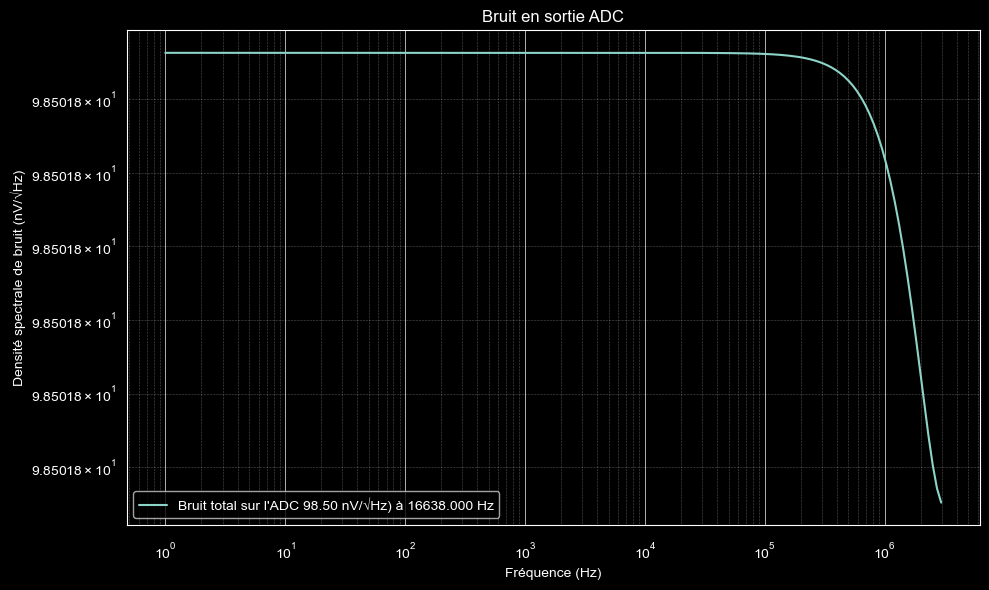

In [295]:
# ajout du bruit de quantification

e_total = np.sqrt(np.ones_like(f_num) * e_adc_q ** 2 + e_fold ** 2)

# ==== AFFICHAGE ====
N_print = 100
freq_print = f_num[N_print]
fig, ax = plt.subplots(figsize=(10, 6))
ax.loglog(f_num, e_total * 1e9,
          label=f"Bruit total sur l'ADC {e_total[N_print] * 1e9:.2f} nV/√Hz) à {freq_print:.3f} Hz")

### Mise en forme ###
ax.set_title("Bruit en sortie ADC")
ax.set_xlabel("Fréquence (Hz)")
ax.set_ylabel("Densité spectrale de bruit (nV/√Hz)")

# grille principale
ax.grid(which='major', linestyle='-', linewidth=0.6, alpha=0.8)
# grille secondaire (optionnelle, plus discrète)
ax.grid(which='minor', linestyle=':', linewidth=0.4, alpha=0.6)

# --- FORCER les graduations secondaires (minor ticks) ---
# Major ticks : puissances de 10 (10^n)
ax.xaxis.set_major_locator(LogLocator(base=10.0, numticks=15))
ax.yaxis.set_major_locator(LogLocator(base=10.0, numticks=15))

# Minor ticks : entre 2,3,...,9 * 10^n
ax.xaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10), numticks=100))
ax.yaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10), numticks=100))

# Ajuster l'apparence des ticks
ax.tick_params(which='major', length=8, width=1)
ax.tick_params(which='minor', length=4, width=0.8, color='gray')

ax.legend()
plt.tight_layout()
plt.show()


In [296]:
export_2vectors_to_file(f_num, e_total, data_filename)


# Bruit de la chaîne OFCO rebouclée sur ADC

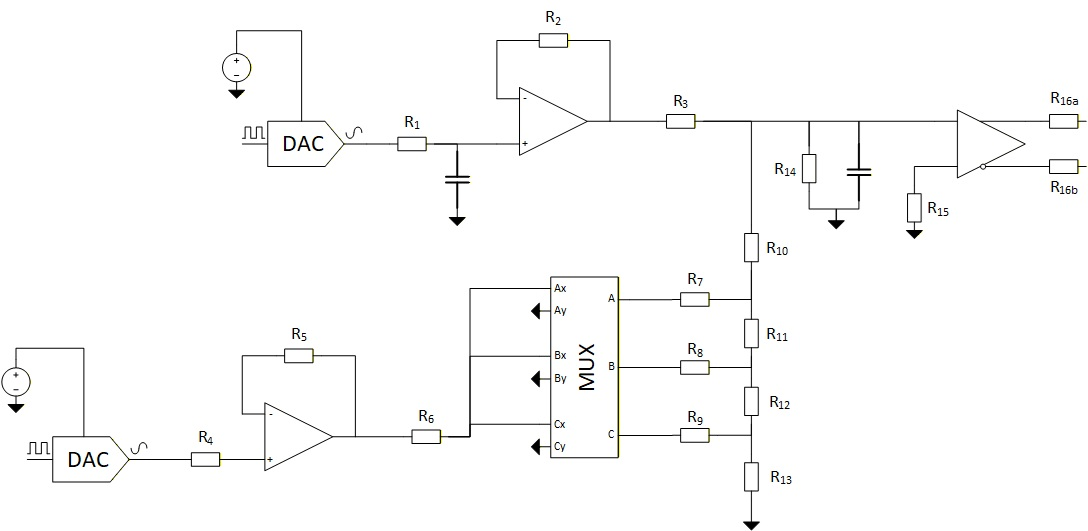

Le modèle de bruit est travaillé en deux temps. Le modèle seul de l'OFCO puis la simplification de ce modèle ramené sur la voie ADC:

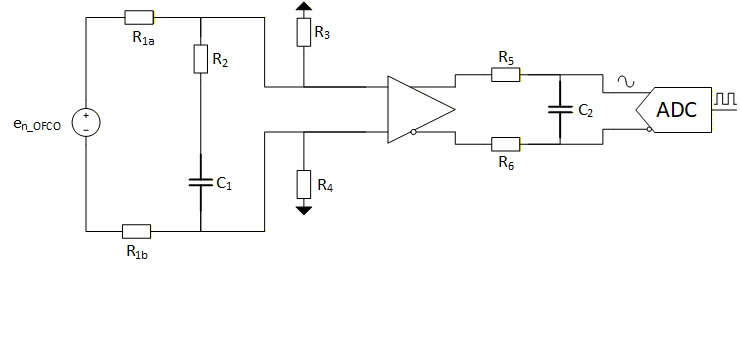

## Partie OFCO seule

In [297]:
data_filename = 'mod-erro-ofco' + data_filename_ext

#Température
T = 25  #°C

### Résistances ###
R1 = 2e3
R2 = 2e3
R3 = 1e3
R4 = 2e3
R5 = 2e3
R6 = 50
R7 = 1e3
R8 = 1e3
R9 = 1e3
R10 = 499
R11 = 499
R12 = 499
R13 = 1e3
R14 = 249
R15 = 169
R16a = 49.9
R16b = 49.9

er1 = thermal_noise(R1, Celsius2Kelvin(T))
er2 = thermal_noise(R2, Celsius2Kelvin(T))
er3 = thermal_noise(R3, Celsius2Kelvin(T))
er4 = thermal_noise(R4, Celsius2Kelvin(T))
er5 = thermal_noise(R5, Celsius2Kelvin(T))
er6 = thermal_noise(R6, Celsius2Kelvin(T))
er7 = thermal_noise(R7, Celsius2Kelvin(T))
er8 = thermal_noise(R8, Celsius2Kelvin(T))
er9 = thermal_noise(R9, Celsius2Kelvin(T))
er10 = thermal_noise(R10, Celsius2Kelvin(T))
er11 = thermal_noise(R11, Celsius2Kelvin(T))
er12 = thermal_noise(R12, Celsius2Kelvin(T))
er13 = thermal_noise(R13, Celsius2Kelvin(T))
er14 = thermal_noise(R14, Celsius2Kelvin(T))
er15 = thermal_noise(R15, Celsius2Kelvin(T))
er16a = thermal_noise(R16a, Celsius2Kelvin(T))
er16b = thermal_noise(R16b, Celsius2Kelvin(T))

### Actifs ###
##ADA4084
e_ada4084 = 3.9e-9  #V/rtHz1kHz
in_ada4084 = 0.55e-12  #pA/rtHz
e_bf_ada4084 = 0.14e-6  #Vpp sur 0.1 à 10Hz
#RHF200
e_rhf_o_gain1 = 10e-9
e_rhf_o_gain2 = 15e-9

### Fonction de transfert de l'ADA4084 et bruit

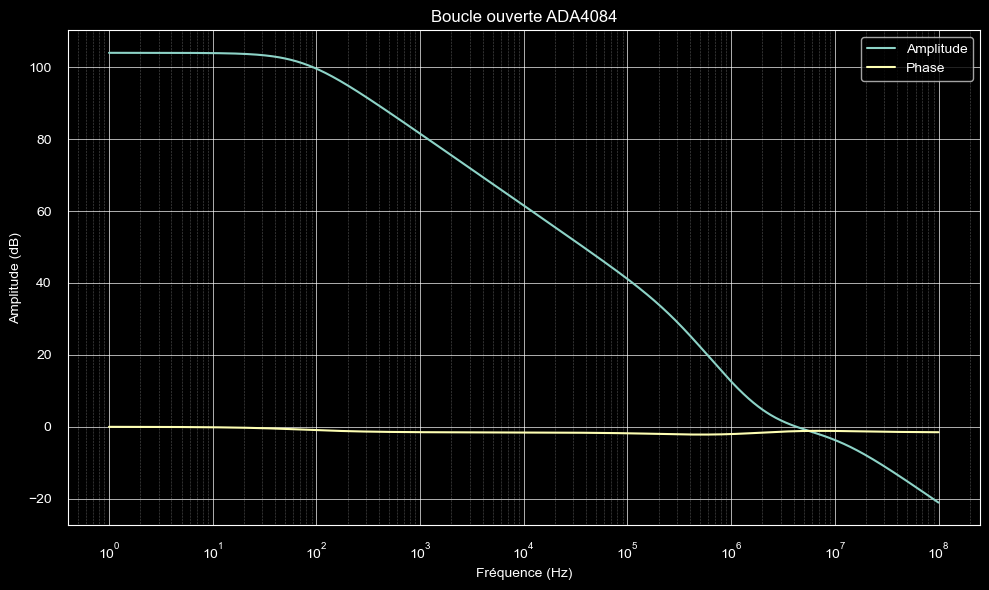

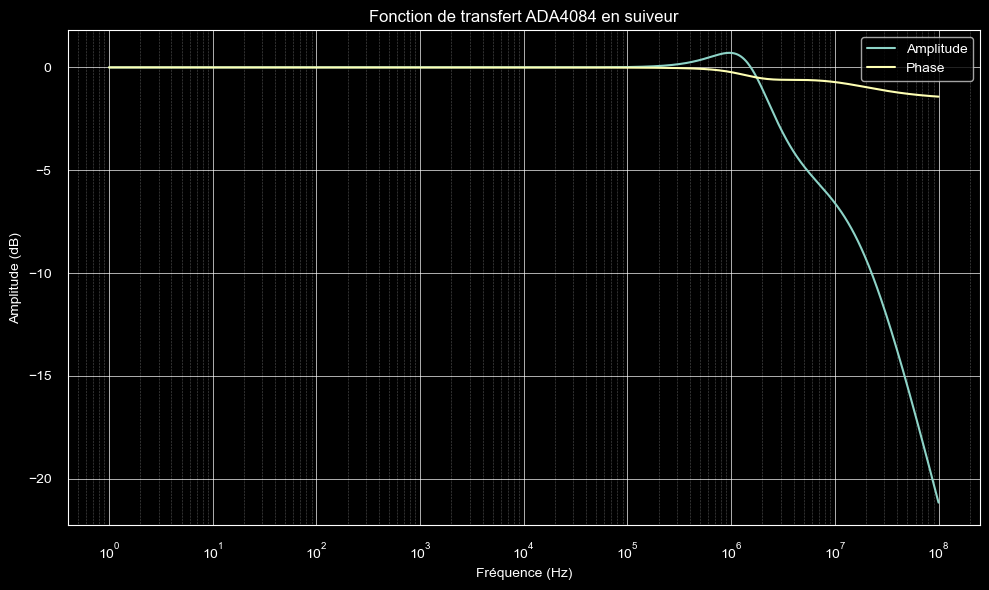

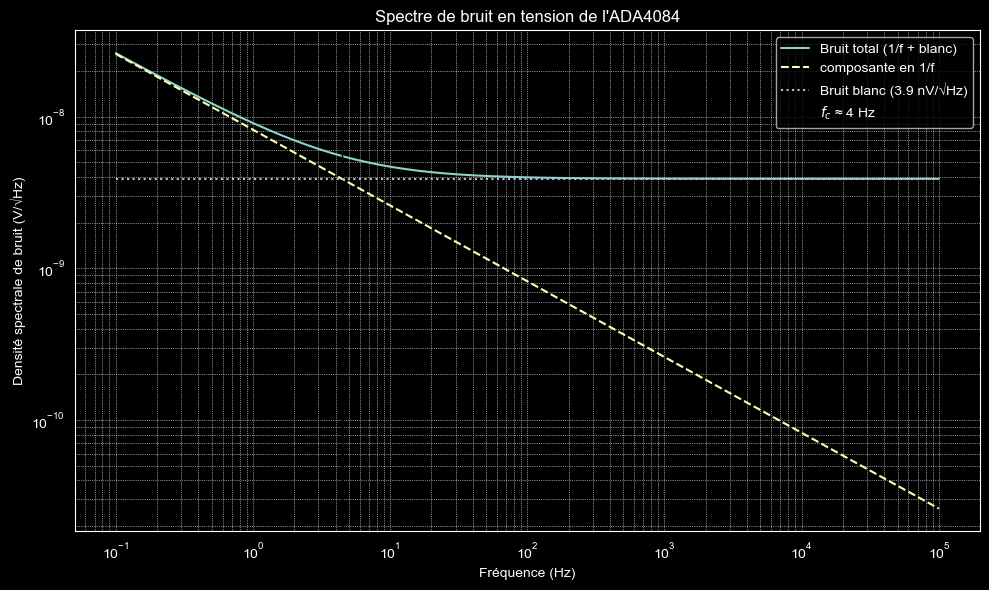

K = 6.760e-17 V² (puissance de bruit en 1/f = K/f)


In [298]:
#Gain de l'ADA4084
GBP = 15.9e6  #Produit gain bande en Hz
AvodB = 104  #dB
Avo = 10 ** (AvodB / 20)
UGC = 9.9e6  #Unity Gain Crossover en Hz
#relevé des fréquences remarquables sur graph
fc3 = 2e6
fc2 = 300e3
Amp_fc2_dB = 32  #dB
Amp_fc2 = 10 ** (Amp_fc2_dB / 20)
#calcul des fréquences des poles et zeros
#dernier zero
tau4 = 1 / (2 * np.pi * UGC)
#pole
tau3 = 1 / (2 * np.pi * fc3)
#zero
tau2 = 1 / (2 * np.pi * fc2)
#zero
fc1 = (Amp_fc2 * fc2) / Avo
tau1 = 1 / (2 * np.pi * fc1)
#fonction de transfert en BO
#print(f"Gain: {Avo}")
#print(fc1,fc2,fc3,UGC)
H_ADA4084_BO = lambda w: Avo * (1 + 1j * tau3 * w) ** 2 / (
            (1 + 1j * tau1 * w) * (1 + 1j * tau2 * w) * (1 + 1j * tau4 * w))

########## Tracé de la fonction de transfert pour comparaison à la datasheet #################
# --- Paramètres ---
f = np.logspace(0, 8, 1000)  # 1 Hz à 100MHz
w = 2 * np.pi * f

Amp_ADA4084 = lambda w: 20 * np.log10(np.abs(H_ADA4084_BO(w)))
phase_ADA4084 = lambda w: np.angle(H_ADA4084_BO(w))

fig, ax = plt.subplots(figsize=(10, 6))
ax.semilogx(f, Amp_ADA4084(w), label="Amplitude")
ax.semilogx(f, phase_ADA4084(w), label="Phase")

### Mise en forme ###
ax.set_title("Boucle ouverte ADA4084")
ax.set_xlabel("Fréquence (Hz)")
ax.set_ylabel("Amplitude (dB)")

# grille principale
ax.grid(which='major', linestyle='-', linewidth=0.6, alpha=0.8)
# grille secondaire (optionnelle, plus discrète)
ax.grid(which='minor', linestyle=':', linewidth=0.4, alpha=0.6)

# --- FORCER les graduations secondaires (minor ticks) ---
# Major ticks : puissances de 10 (10^n)
ax.xaxis.set_major_locator(LogLocator(base=10.0, numticks=15))
#ax.yaxis.set_major_locator(LogLocator(base=10.0, numticks=15))

# Minor ticks : entre 2,3,...,9 * 10^n
# Utiliser subs = np.arange(2,10) (valeurs 2..9). Certains anciens matplotlib
# acceptent subs as list/tuple; ici on passe un ndarray.
ax.xaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10), numticks=100))
#ax.yaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2,10), numticks=100))

# Ajuster l'apparence des ticks
ax.tick_params(which='major', length=8, width=1)
ax.tick_params(which='minor', length=4, width=0.8, color='gray')

ax.legend()
plt.tight_layout()
plt.show()

## Par la suite cet AOP est utilisé en suiveur et il n'y a pas de courant / chute de tension dans la résistance de feedback

H_ADA4084_BF = lambda w: H_ADA4084_BO(w) / (1 + H_ADA4084_BO(w))

Amp_ADA4084 = lambda w: 20 * np.log10(np.abs(H_ADA4084_BF(w)))
phase_ADA4084 = lambda w: np.angle(H_ADA4084_BF(w))

fig, ax = plt.subplots(figsize=(10, 6))
ax.semilogx(f, Amp_ADA4084(w), label="Amplitude")
ax.semilogx(f, phase_ADA4084(w), label="Phase")

### Mise en forme ###
ax.set_title("Fonction de transfert ADA4084 en suiveur")
ax.set_xlabel("Fréquence (Hz)")
ax.set_ylabel("Amplitude (dB)")

# grille principale
ax.grid(which='major', linestyle='-', linewidth=0.6, alpha=0.8)
# grille secondaire (optionnelle, plus discrète)
ax.grid(which='minor', linestyle=':', linewidth=0.4, alpha=0.6)

# --- FORCER les graduations secondaires (minor ticks) ---
# Major ticks : puissances de 10 (10^n)
ax.xaxis.set_major_locator(LogLocator(base=10.0, numticks=15))
#ax.yaxis.set_major_locator(LogLocator(base=10.0, numticks=15))

# Minor ticks : entre 2,3,...,9 * 10^n
# Utiliser subs = np.arange(2,10) (valeurs 2..9). Certains anciens matplotlib
# acceptent subs as list/tuple; ici on passe un ndarray.
ax.xaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10), numticks=100))
#ax.yaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2,10), numticks=100))

# Ajuster l'apparence des ticks
ax.tick_params(which='major', length=8, width=1)
ax.tick_params(which='minor', length=4, width=0.8, color='gray')

ax.legend()
plt.tight_layout()
plt.show()

#partie bruit
#Sur la datasheet, on peut estimer le bruit en 1/f à 9.1nV à 1Hz environ.La corner frequency semble aux alentours de 18Hz
# === Calculs ===
K_ada4084 = (9.1e-9) ** 2 - e_ada4084 ** 2  # Coefficient du bruit 1/f
fc_ada4084 = K_ada4084 / (e_ada4084 ** 2)  # Fréquence de coin (corner frequency)

# === Fréquences ===
f = np.logspace(-1, 5, 1000)  # De 0.1 Hz à 100 kHz

# === Composantes de bruit ===
e_1f_ada4084 = np.sqrt(K_ada4084 / f)  # Contribution 1/f
e_total_ada4084 = np.sqrt(e_ada4084 ** 2 + K_ada4084 / f)  # Bruit total (1/f + blanc)
e_white_line_ada4084 = np.ones_like(f) * e_ada4084

# === Tracé ===
plt.figure(figsize=(10, 6))
plt.loglog(f, e_total_ada4084, label="Bruit total (1/f + blanc)")
plt.loglog(f, e_1f_ada4084, linestyle='--', label="composante en 1/f")
plt.loglog(f, e_white_line_ada4084, linestyle=':', label=f"Bruit blanc ({e_ada4084 * 1e9:.1f} nV/√Hz)")
plt.axvline(fc_ada4084, linestyle='-.', linewidth=1, color='k', label=f"$f_c$ ≈ {fc_ada4084:.0f} Hz")

# === Mise en forme ===
plt.xlabel("Fréquence (Hz)")
plt.ylabel("Densité spectrale de bruit (V/√Hz)")
plt.title("Spectre de bruit en tension de l'ADA4084")
plt.legend()
plt.grid(which='both', linestyle=':', linewidth=0.5)
plt.tight_layout()

# === Affichage ===
plt.show()
print(f"K = {K_ada4084:.3e} V² (puissance de bruit en 1/f = K/f)")  #gain du 1/f

#Fonction de bruit pour les deux suiveur ADA4084
en_total_ada4084 = lambda w: np.sqrt(e_ada4084 ** 2 + K_ada4084 / (w / (np.pi * 2)))
e_ada4084_coarse = lambda w: np.sqrt(
    en_total_ada4084(w) ** 2 + (in_ada4084 ** 2) * (R2 ** 2 + R1 ** 2 / (1 + 1j * R1 * C1 * w) ** 2))
e_ada4084_fine = lambda w: np.sqrt(en_total_ada4084(w) ** 2 + (in_ada4084 ** 2) * (R5 ** 2 + R4 ** 2))

### Modèle référence de tension

K = 4.19347494350015e-11
bruit à 1Hz: 6.475704551243942e-06
e_white = 1.1920965921413415e-06


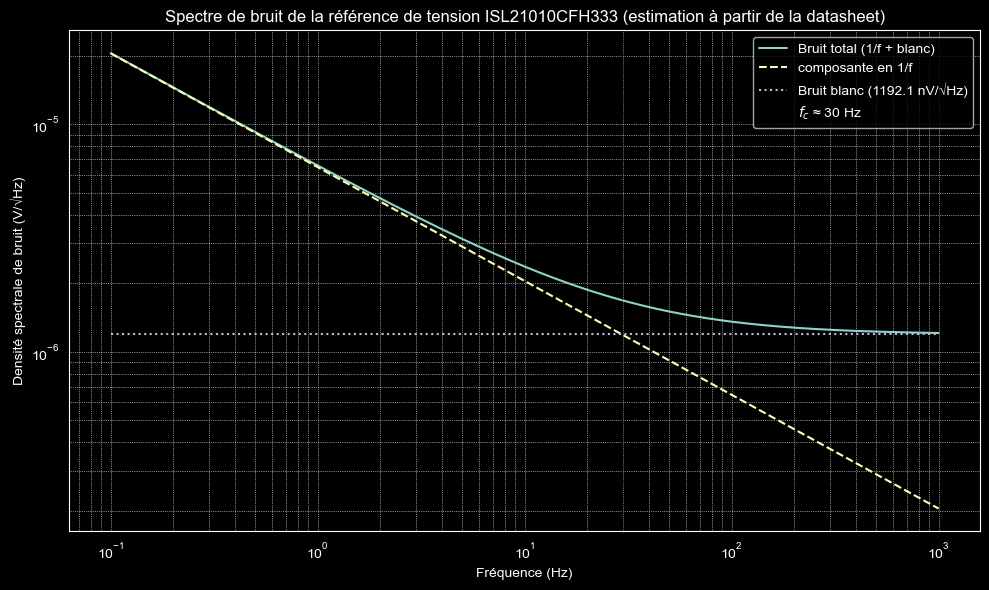

In [299]:
#Référence de tension ISL2110CHF333

#Le soucis est de remonter au bruit 1/F et bruit blanc:

# Bandes
f1_low, f1_high = 0.1, 10
f2_low, f2_high = 10, 1000

# Mesures
noise1_pp = 95e-6
noise2_rms = 40e-6

# Conversion pp → RMS (approximation) En vrai cela dépend du nombre de points: Vpp = 2*sigma * sqrt(2*ln(N)) et non Vpp = 6 * sigma
noise1_rms = noise1_pp / 6.6  # trouvé dans la littérature comme approche prudente pour ce cas.

P1 = noise1_rms ** 2
P2 = noise2_rms ** 2

A1 = np.log(f1_high / f1_low)
A2 = np.log(f2_high / f2_low)

B1 = f1_high - f1_low
B2 = f2_high - f2_low

# Résolution analytique
e_white_sq = (P2 - P1) / (B2 - B1)
K = (P1 - B1 * e_white_sq) / A1

e_white = np.sqrt(e_white_sq)

print("K =", K)
print(f"bruit à 1Hz: {np.sqrt(K)}")
print("e_white =", e_white)

# === Fréquences ===
f = np.logspace(-1, 3, 1000)  # De 0.1 Hz à 1 kHz

# === Composantes de bruit ===
fc = K / (e_white ** 2)  # Fréquence de coin (corner frequency)
e_1f = np.sqrt(K / f)  # Contribution 1/f
e_total = np.sqrt(e_white ** 2 + K / f)  # Bruit total (1/f + blanc)
e_white_line = np.ones_like(f) * e_white  #bruit blanc

# === Tracé ===
plt.figure(figsize=(10, 6))
plt.loglog(f, e_total, label="Bruit total (1/f + blanc)")
plt.loglog(f, e_1f, linestyle='--', label="composante en 1/f")
plt.loglog(f, e_white_line, linestyle=':', label=f"Bruit blanc ({e_white * 1e9:.1f} nV/√Hz)")
plt.axvline(fc, linestyle='-.', linewidth=1, color='k', label=f"$f_c$ ≈ {fc:.0f} Hz")

# === Mise en forme ===
plt.xlabel("Fréquence (Hz)")
plt.ylabel("Densité spectrale de bruit (V/√Hz)")
plt.title("Spectre de bruit de la référence de tension ISL21010CFH333 (estimation à partir de la datasheet)")
plt.legend()
plt.grid(which='both', linestyle=':', linewidth=0.5)
plt.tight_layout()

# === Affichage ===
plt.show()

e_isl = lambda w: np.sqrt(e_white ** 2 + K / (w / (np.pi * 2)))

### Rejection du bruit de la ref de tension par les capacités de découplage du DAC

La référence de tension possède l'impédance de sortie suivante:

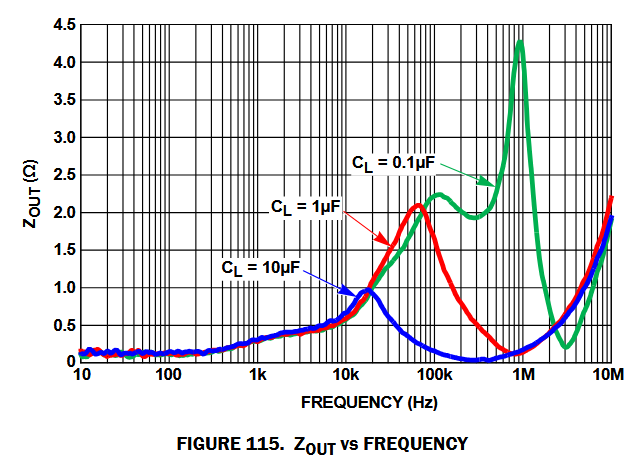

La modélisation proposée est la suivante.

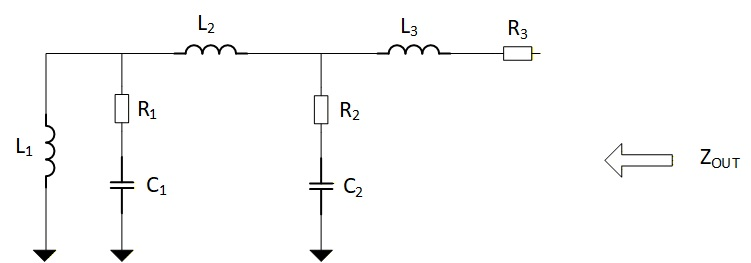



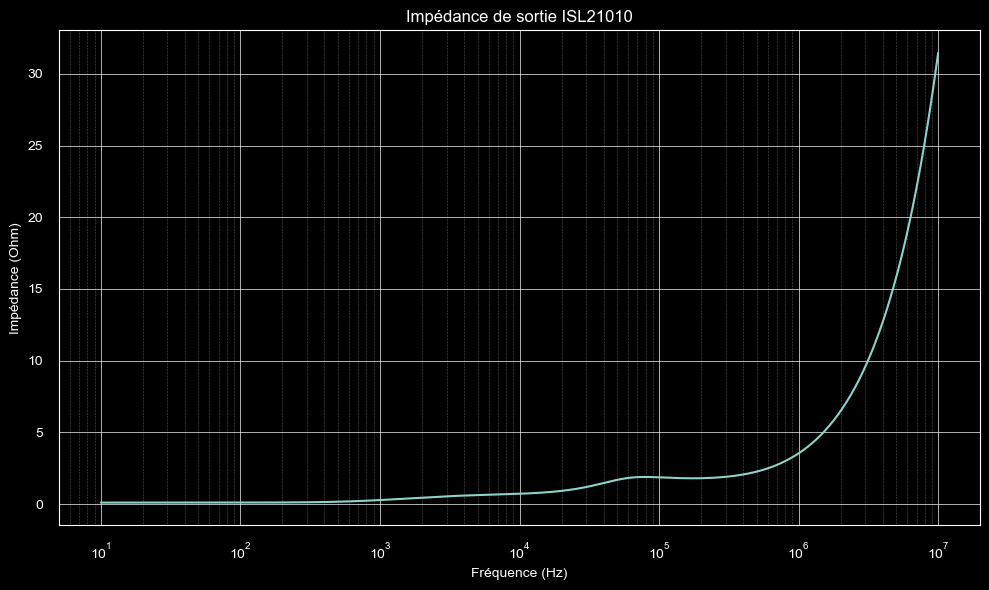

In [300]:
def z_out_ISL(w):
    R1 = 0.5
    C1 = 800e-6  #800e-6
    L1 = 30e-6

    L2 = 4e-6
    R2 = 1.5
    C2 = 1.9e-6

    L3 = 500e-9

    R3 = 0.1

    Z1 = lambda w: R1 + 1 / (1j * C1 * w)
    Z2 = lambda w: Z1(w) * 1j * L1 * w / (Z1(w) + 1j * L1 * w) + 1j * L2 * w
    Z3 = lambda w: R2 + 1 / (1j * C2 * w)

    return Z2(w) * Z3(w) / (Z2(w) + Z3(w)) + 1j * L3 * w + R3


import matplotlib.pyplot as plt
from matplotlib.ticker import LogLocator

# --- Paramètres ---
f = np.logspace(1, 7, 1000)  # 10 Hz à 10 MHz
w = 2 * np.pi * f

fig, ax = plt.subplots(figsize=(10, 6))
ax.semilogx(f, np.abs(z_out_ISL(w)))
### Mise en forme ###
ax.set_title("Impédance de sortie ISL21010")
ax.set_xlabel("Fréquence (Hz)")
ax.set_ylabel("Impédance (Ohm)")

# grille principale
ax.grid(which='major', linestyle='-', linewidth=0.6, alpha=0.8)
# grille secondaire (optionnelle, plus discrète)
ax.grid(which='minor', linestyle=':', linewidth=0.4, alpha=0.6)

# --- FORCER les graduations secondaires (minor ticks) ---
# Major ticks : puissances de 10 (10^n)
ax.xaxis.set_major_locator(LogLocator(base=10.0, numticks=15))

# Minor ticks : entre 2,3,...,9 * 10^n
# Utiliser subs = np.arange(2,10) (valeurs 2..9). Certains anciens matplotlib
# acceptent subs as list/tuple; ici on passe un ndarray.
ax.xaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10), numticks=100))

# Ajuster l'apparence des ticks
ax.tick_params(which='major', length=8, width=1)
ax.tick_params(which='minor', length=4, width=0.8, color='gray')

#ax.legend()
plt.tight_layout()
plt.show()


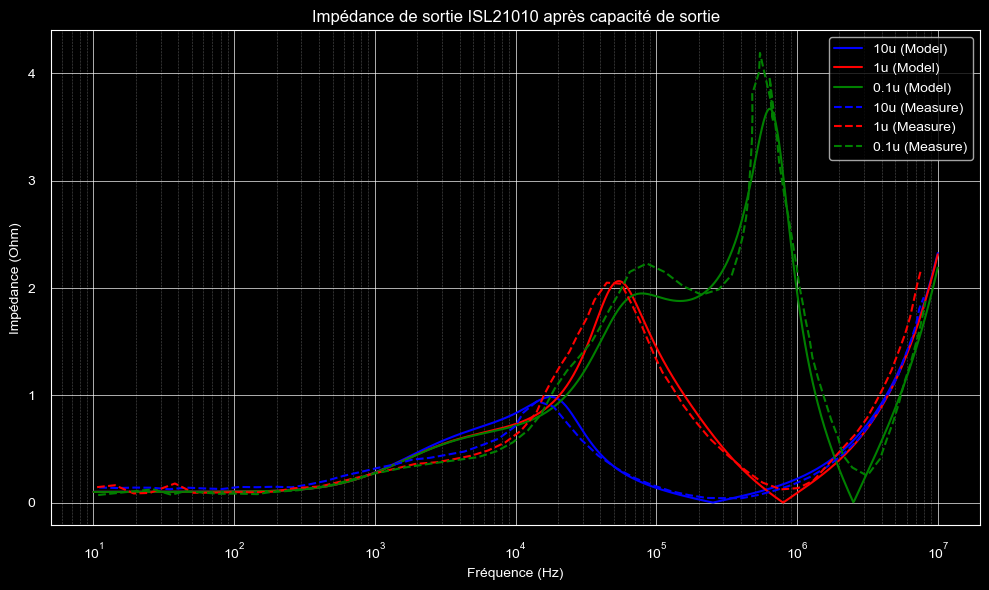

In [301]:
#Impedance sous 10µF, 1µF, 0.1µF (comparaison avec courbe datasheet)

Lcapa_piste = 40e-9

Z_10u = lambda w: 1j * Lcapa_piste * w + 1 / (1j * 10e-6 * w)
Z_1u = lambda w: 1j * Lcapa_piste * w + 1 / (1j * 1e-6 * w)
Z_01u = lambda w: 1j * Lcapa_piste * w + 1 / (1j * 100e-9 * w)

Zisl_10u = lambda w: z_out_ISL(w) * Z_10u(w) / (z_out_ISL(w) + Z_10u(w))
Zisl_1u = lambda w: z_out_ISL(w) * Z_1u(w) / (z_out_ISL(w) + Z_1u(w))
Zisl_01u = lambda w: z_out_ISL(w) * Z_01u(w) / (z_out_ISL(w) + Z_01u(w))

##datasheet numérisée
import csv


def read_csv_to_dict(file_path):
    data_dict = {
        '10µF': {'X': [], 'Y': []},
        '1µF': {'X': [], 'Y': []},
        '100nF': {'X': [], 'Y': []}
    }

    with open(file_path, mode='r') as csv_file:
        # Lire la première ligne pour ignorer les en-têtes inutiles
        next(csv_file)
        # Lire la ligne suivante qui contient les vrais en-têtes
        headers = next(csv_file).strip().split(',')

        csv_reader = csv.reader(csv_file)

        for row in csv_reader:
            # Vérifier que la ligne n'est pas vide et contient assez de colonnes
            if len(row) >= 6:
                try:
                    # Convertir chaque valeur en float, ignorer si vide
                    x_10uF = float(row[0]) if row[0] else None
                    y_10uF = float(row[1]) if row[1] else None
                    x_1uF = float(row[2]) if row[2] else None
                    y_1uF = float(row[3]) if row[3] else None
                    x_100nF = float(row[4]) if row[4] else None
                    y_100nF = float(row[5]) if row[5] else None

                    # Ajouter les valeurs au dictionnaire si elles ne sont pas None
                    if x_10uF is not None:
                        data_dict['10µF']['X'].append(x_10uF)
                    if y_10uF is not None:
                        data_dict['10µF']['Y'].append(y_10uF)
                    if x_1uF is not None:
                        data_dict['1µF']['X'].append(x_1uF)
                    if y_1uF is not None:
                        data_dict['1µF']['Y'].append(y_1uF)
                    if x_100nF is not None:
                        data_dict['100nF']['X'].append(x_100nF)
                    if y_100nF is not None:
                        data_dict['100nF']['Y'].append(y_100nF)
                except ValueError as e:
                    print(f"Erreur de conversion : {e}. Ligne ignorée : {row}")

    return data_dict


datasheet = read_csv_to_dict('isl21010_datasets.csv')

fig, ax = plt.subplots(figsize=(10, 6))
ax.semilogx(f, np.abs(Zisl_10u(w)), label="10u (Model)", color="b")
ax.semilogx(f, np.abs(Zisl_1u(w)), label="1u (Model)", color="r")
ax.semilogx(f, np.abs(Zisl_01u(w)), label="0.1u (Model)", color="g")
ax.semilogx(datasheet['10µF']['X'], datasheet['10µF']['Y'], label="10u (Measure)", color="b", linestyle="dashed")
ax.semilogx(datasheet['1µF']['X'], datasheet['1µF']['Y'], label="1u (Measure)", color="r", linestyle="dashed")
ax.semilogx(datasheet['100nF']['X'], datasheet['100nF']['Y'], label="0.1u (Measure)", color="g", linestyle="dashed")
### Mise en forme ###
ax.set_title("Impédance de sortie ISL21010 après capacité de sortie")
ax.set_xlabel("Fréquence (Hz)")
ax.set_ylabel("Impédance (Ohm)")

# grille principale
ax.grid(which='major', linestyle='-', linewidth=0.6, alpha=0.8)
# grille secondaire (optionnelle, plus discrète)
ax.grid(which='minor', linestyle=':', linewidth=0.4, alpha=0.6)

# --- FORCER les graduations secondaires (minor ticks) ---
# Major ticks : puissances de 10 (10^n)
ax.xaxis.set_major_locator(LogLocator(base=10.0, numticks=15))

# Minor ticks : entre 2,3,...,9 * 10^n
# Utiliser subs = np.arange(2,10) (valeurs 2..9). Certains anciens matplotlib
# acceptent subs as list/tuple; ici on passe un ndarray.
ax.xaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10), numticks=100))

# Ajuster l'apparence des ticks
ax.tick_params(which='major', length=8, width=1)
ax.tick_params(which='minor', length=4, width=0.8, color='gray')

ax.legend()
plt.tight_layout()
plt.show()

### Bruit rapporté par la référence de tension en sortie de DAC:

Une ref de tension est partagée entre les deux DACs lents. De la datasheet, on peut considérer que les DAC121S101 présentent une impédance vis à vis de leur source d'alimentation de 36kOhms.

Les inductances de piste entre les DACs sont négligées ce qui fait que le schéma peut être simplifié comme suit:


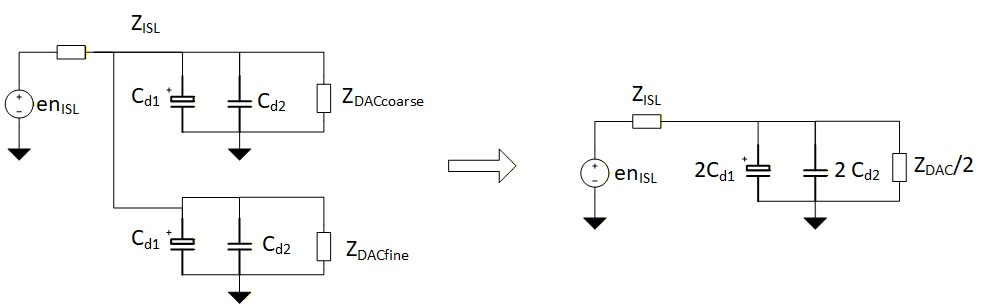



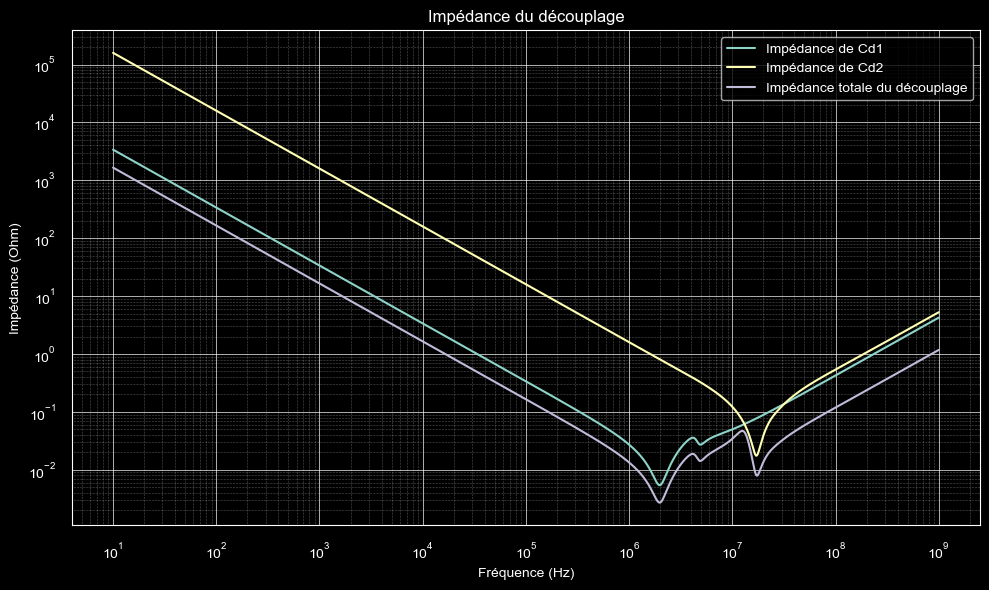

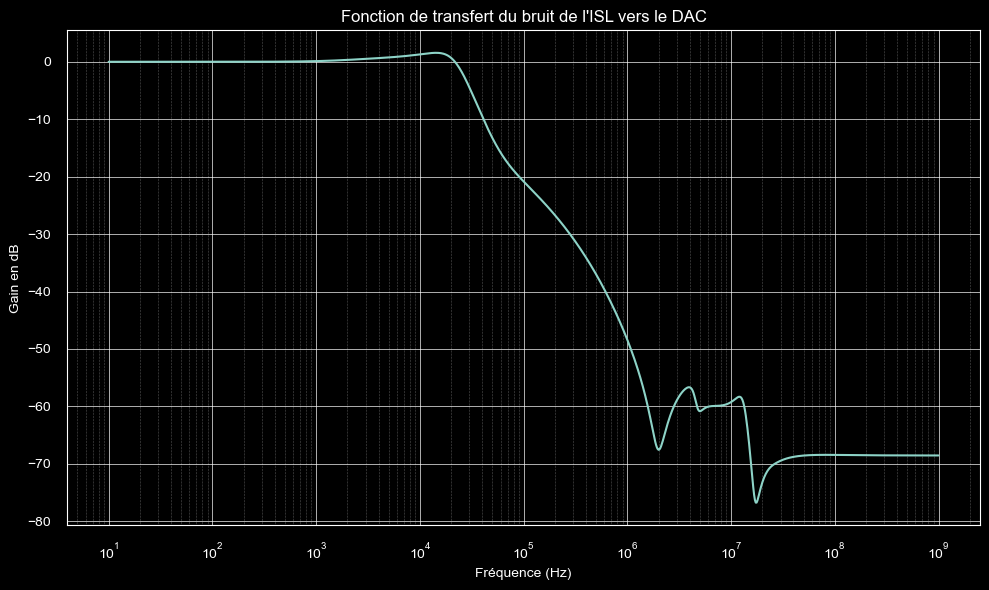

In [302]:
#Fonction de transfert du bruit

#Cd1 datasheet model (300904106475JC)
def Z_Cd1(w):
    R0 = 1.905e-3
    R1 = 3.597e-3
    R2 = 71.83e-3
    R3 = 72.15e-3
    R4 = 1e9
    L1 = 1.685e-9
    L2 = 1.246e-9
    L3 = 11.99e-9
    C1 = 3.807e-6
    C2 = 799e-9
    C3 = 94e-9

    Z1 = lambda w: 1j * L1 * w + R1 + 1 / (1j * C1 * w)
    Z2 = lambda w: 1j * L2 * w + R2 + 1 / (1j * C2 * w)
    Z3 = lambda w: 1j * L3 * w + R3 + 1 / (1j * C3 * w)

    return R0 + 1 / (1 / Z1(w) + 1 / Z2(w) + 1 / Z3(w) + 1 / R4)


#Cd2 datasheet model (300904102104JC)
def Z_Cd2(w):
    R0 = 100e-6
    R1 = 17.54e-3
    R2 = 2.449
    R3 = 1.385
    R4 = 1e9
    L1 = 1.041e-9
    L2 = 5.32e-9
    L3 = 21.96e-9
    C1 = 83e-9
    C2 = 15e-9
    C3 = 1.9e-9

    Z1 = lambda w: 1j * L1 * w + R1 + 1 / (1j * C1 * w)
    Z2 = lambda w: 1j * L2 * w + R2 + 1 / (1j * C2 * w)
    Z3 = lambda w: 1j * L3 * w + R3 + 1 / (1j * C3 * w)

    return R0 + 1 / (1 / Z1(w) + 1 / Z2(w) + 1 / Z3(w) + 1 / R4)


Z_Cd = lambda w: 1 / (2 / (Z_Cd1(w)) + 2 / (Z_Cd2(w)))

#Plot des paramètres seuls puis combiaison
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import LogLocator

# --- Paramètres ---
f = np.logspace(1, 9, 1000)  # 10 Hz à 1 GHz
w = 2 * np.pi * f

fig, ax = plt.subplots(figsize=(10, 6))
ax.loglog(f, np.abs(Z_Cd1(w)), label="Impédance de Cd1")
ax.loglog(f, np.abs(Z_Cd2(w)), label="Impédance de Cd2")
ax.loglog(f, np.abs(Z_Cd(w)), label="Impédance totale du découplage")

### Mise en forme ###
ax.set_title("Impédance du découplage")
ax.set_xlabel("Fréquence (Hz)")
ax.set_ylabel("Impédance (Ohm)")

# grille principale
ax.grid(which='major', linestyle='-', linewidth=0.6, alpha=0.8)
# grille secondaire (optionnelle, plus discrète)
ax.grid(which='minor', linestyle=':', linewidth=0.4, alpha=0.6)

# --- FORCER les graduations secondaires (minor ticks) ---
# Major ticks : puissances de 10 (10^n)
ax.xaxis.set_major_locator(LogLocator(base=10.0, numticks=15))
ax.yaxis.set_major_locator(LogLocator(base=10.0, numticks=15))

# Minor ticks : entre 2,3,...,9 * 10^n
# Utiliser subs = np.arange(2,10) (valeurs 2..9). Certains anciens matplotlib
# acceptent subs as list/tuple; ici on passe un ndarray.
ax.xaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10), numticks=100))
ax.yaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10), numticks=100))

# Ajuster l'apparence des ticks
ax.tick_params(which='major', length=8, width=1)
ax.tick_params(which='minor', length=4, width=0.8, color='gray')

ax.legend()
plt.tight_layout()
plt.show()

#fonction de transfert du bruit de la ref vers DAC
H_ISL_DAC = lambda w: Z_Cd(w) / (Z_Cd(w) + z_out_ISL(w))

fig, ax = plt.subplots(figsize=(10, 6))
ax.semilogx(f, 20 * np.log10(np.abs(H_ISL_DAC(w))))

### Mise en forme ###
ax.set_title("Fonction de transfert du bruit de l'ISL vers le DAC")
ax.set_xlabel("Fréquence (Hz)")
ax.set_ylabel("Gain en dB")

# grille principale
ax.grid(which='major', linestyle='-', linewidth=0.6, alpha=0.8)
# grille secondaire (optionnelle, plus discrète)
ax.grid(which='minor', linestyle=':', linewidth=0.4, alpha=0.6)

# --- FORCER les graduations secondaires (minor ticks) ---
# Major ticks : puissances de 10 (10^n)
ax.xaxis.set_major_locator(LogLocator(base=10.0, numticks=15))

# Minor ticks : entre 2,3,...,9 * 10^n
# Utiliser subs = np.arange(2,10) (valeurs 2..9). Certains anciens matplotlib
# acceptent subs as list/tuple; ici on passe un ndarray.
ax.xaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10), numticks=100))

# Ajuster l'apparence des ticks
ax.tick_params(which='major', length=8, width=1)
ax.tick_params(which='minor', length=4, width=0.8, color='gray')

plt.tight_layout()
plt.show()

### Calcul des bruits en entrée RHF200

In [303]:
### Capacités de filtrage ###
C1 = 3.3e-9
C2 = 68e-12

#fonction de transfert des dac fine et coarse
H_dac_slow = lambda code: code / 4096

#Résistance équivalente R2R (On considère R6 négligeable)
R2R_eq_b0 = R13 * R9 / (R13 + R9) + R12
R2R_eq_b1 = R2R_eq_b0 * R8 / (R2R_eq_b0 + R8) + R11
R2R_eq_b2 = R2R_eq_b1 * R7 / (R2R_eq_b1 + R7) + R10

print(f"Résistance équivalente au bit 0 du R2R: {R2R_eq_b0:.1f} Ohms")
print(f"Résistance équivalente au bit 1 du R2R: {R2R_eq_b1:.1f} Ohms")
print(f"Résistance équivalente au réseau R2R complet: {R2R_eq_b2:.1f} Ohms")

### Les gains permettent de ramener les bruits en sortie de l'OFCO avant les 50 Ohms d'adaptation ###

#suiveur coarse
Z_R2R = lambda w: R2R_eq_b2 * R14 / (R2R_eq_b2 + R14 + 1j * R2R_eq_b2 * R14 * C1 * w)
H_out_suiveur_coarse = lambda w: Z_R2R(w) / (Z_R2R(w) + R3)

#DAC coarse
H_dac_coarse_out = lambda w: 1 / (1 + 1j * R1 * C1 * w) * H_ADA4084_BF(w) * H_out_suiveur_coarse(w)

#R14
R_vue_r14 = R2R_eq_b2 * R3 / (R2R_eq_b2 + R3)
H_r14 = lambda w: 1 / (1 + R14 / R_vue_r14 + 1j * R14 * C1 * w)

#R2R
#Pour la fonction de transfert du R2R, on considère que R7,R8,R9,R13 = 2R et R10,R11,R12 = R pour alléger le calcul.
H_R2R = lambda code: code / 8
H_R2R_out = lambda w: H_out_suiveur_coarse(w)  #approximation: on présente 1k comme le cas du suiveur coarse

#Le bruit du réseau R2R peut se simplifier aussi avec les égalités sur les résistances précédentes. Il faut lui appliquer H_R2R_out
e_R2R = er13

#Le MUX est considéré sans bruit.

#DAC fine
H_dac_fine_out = lambda w, code: H_ADA4084_BF(w) * H_R2R(code) * H_R2R_out(w)


Résistance équivalente au bit 0 du R2R: 999.0 Ohms
Résistance équivalente au bit 1 du R2R: 998.7 Ohms
Résistance équivalente au réseau R2R complet: 998.7 Ohms


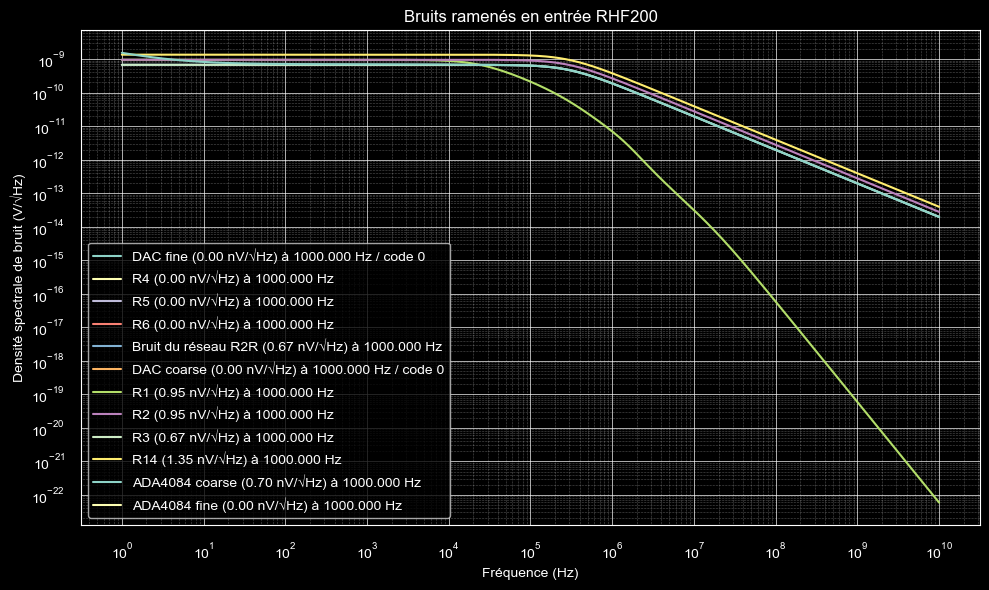

In [304]:
##### Tracé des différentes sources de bruit  OFCO partie R2R####
import matplotlib.pyplot as plt
from matplotlib.ticker import LogLocator

# --- Paramètres ---
f = np.logspace(0, 10, 1000)  # 1 Hz à 10 GHz
w = 2 * np.pi * f

#Valeurs des bruits en entrée du RHF200 de la partie OFCO
e_dac_fine_out = lambda w: np.abs(e_isl(w) * H_ISL_DAC(w) * H_dac_slow(code_fine) * H_dac_fine_out(w, code_fast))
e_r4_out = lambda w: er4 * np.abs(H_dac_fine_out(w, code_fast))
e_r5_out = lambda w: er5 * H_R2R(code_fast) * np.abs(H_R2R_out(w))
e_r6_out = lambda w: er6 * H_R2R(code_fast) * np.abs(H_R2R_out(w))
e_r2r_out = lambda w: e_R2R * np.abs(H_R2R_out(w))
e_dac_coarse_out = lambda w: np.abs(e_isl(w) * H_ISL_DAC(w) * H_dac_slow(code_coarse) * H_dac_coarse_out(w))
e_r1_out = lambda w: er1 * np.abs(H_dac_coarse_out(w))
e_r2_out = lambda w: er2 * np.abs(H_out_suiveur_coarse(w))
e_r3_out = lambda w: er3 * np.abs(H_out_suiveur_coarse(w))
e_r14_out = lambda w: er14 * np.abs(H_r14(w))
e_ada4084_coarse_out = lambda w: np.abs(e_ada4084_coarse(w) * H_out_suiveur_coarse(w))
e_ada4084_fine_out = lambda w: np.abs(e_ada4084_fine(w) * H_R2R(code_fast) * H_R2R_out(w))

#e_total_in_adc = lambda w: np.sqrt(e_dac_out(w)**2+erhf_dac_out(w)**2+er0_out(w)**2+er1_out(w)**2+er2_out(w)**2+er3_out(w)**2+er4_out(w)**2+er5_out(w)**2+er6_out(w)**2+erhf_adc_out(w)**2+e_adc_th_out(w)**2+e_miror_out(w)**2)

# --- Tracé ---
freq_print = 1e3  # fréquence pour laquelle on met la mesure du bruit en légende
w_print = 2 * np.pi * freq_print
fig, ax = plt.subplots(figsize=(10, 6))
ax.loglog(f, e_dac_fine_out(w),
          label=f"DAC fine ({e_dac_fine_out(w_print) * 1e9:.2f} nV/√Hz) à {freq_print:.3f} Hz / code {code_fine}")
ax.loglog(f, e_r4_out(w), label=f"R4 ({e_r4_out(w_print) * 1e9:.2f} nV/√Hz) à {freq_print:.3f} Hz")
ax.loglog(f, e_r5_out(w), label=f"R5 ({e_r5_out(w_print) * 1e9:.2f} nV/√Hz) à {freq_print:.3f} Hz")
ax.loglog(f, e_r6_out(w), label=f"R6 ({e_r6_out(w_print) * 1e9:.2f} nV/√Hz) à {freq_print:.3f} Hz")
ax.loglog(f, e_r2r_out(w), label=f"Bruit du réseau R2R ({e_r2r_out(w_print) * 1e9:.2f} nV/√Hz) à {freq_print:.3f} Hz")
ax.loglog(f, e_dac_coarse_out(w),
          label=f"DAC coarse ({e_dac_coarse_out(w_print) * 1e9:.2f} nV/√Hz) à {freq_print:.3f} Hz / code {code_coarse}")
ax.loglog(f, e_r1_out(w), label=f"R1 ({e_r1_out(w_print) * 1e9:.2f} nV/√Hz) à {freq_print:.3f} Hz")
ax.loglog(f, e_r2_out(w), label=f"R2 ({e_r2_out(w_print) * 1e9:.2f} nV/√Hz) à {freq_print:.3f} Hz")
ax.loglog(f, e_r3_out(w), label=f"R3 ({e_r3_out(w_print) * 1e9:.2f} nV/√Hz) à {freq_print:.3f} Hz")
ax.loglog(f, e_r14_out(w), label=f"R14 ({e_r14_out(w_print) * 1e9:.2f} nV/√Hz) à {freq_print:.3f} Hz")
ax.loglog(f, e_ada4084_coarse_out(w),
          label=f"ADA4084 coarse ({e_ada4084_coarse_out(w_print) * 1e9:.2f} nV/√Hz) à {freq_print:.3f} Hz")
ax.loglog(f, e_ada4084_fine_out(w),
          label=f"ADA4084 fine ({e_ada4084_fine_out(w_print) * 1e9:.2f} nV/√Hz) à {freq_print:.3f} Hz")

### Mise en forme ###
ax.set_title("Bruits ramenés en entrée RHF200")
ax.set_xlabel("Fréquence (Hz)")
ax.set_ylabel("Densité spectrale de bruit (V/√Hz)")

# grille principale
ax.grid(which='major', linestyle='-', linewidth=0.6, alpha=0.8)
# grille secondaire (optionnelle, plus discrète)
ax.grid(which='minor', linestyle=':', linewidth=0.4, alpha=0.6)

# --- FORCER les graduations secondaires (minor ticks) ---
# Major ticks : puissances de 10 (10^n)
ax.xaxis.set_major_locator(LogLocator(base=10.0, numticks=15))
ax.yaxis.set_major_locator(LogLocator(base=10.0, numticks=15))

# Minor ticks : entre 2,3,...,9 * 10^n
# Utiliser subs = np.arange(2,10) (valeurs 2..9). Certains anciens matplotlib
# acceptent subs as list/tuple; ici on passe un ndarray.
ax.xaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10), numticks=100))
ax.yaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10), numticks=100))

# Ajuster l'apparence des ticks
ax.tick_params(which='major', length=8, width=1)
ax.tick_params(which='minor', length=4, width=0.8, color='gray')

ax.legend()
plt.tight_layout()
plt.show()

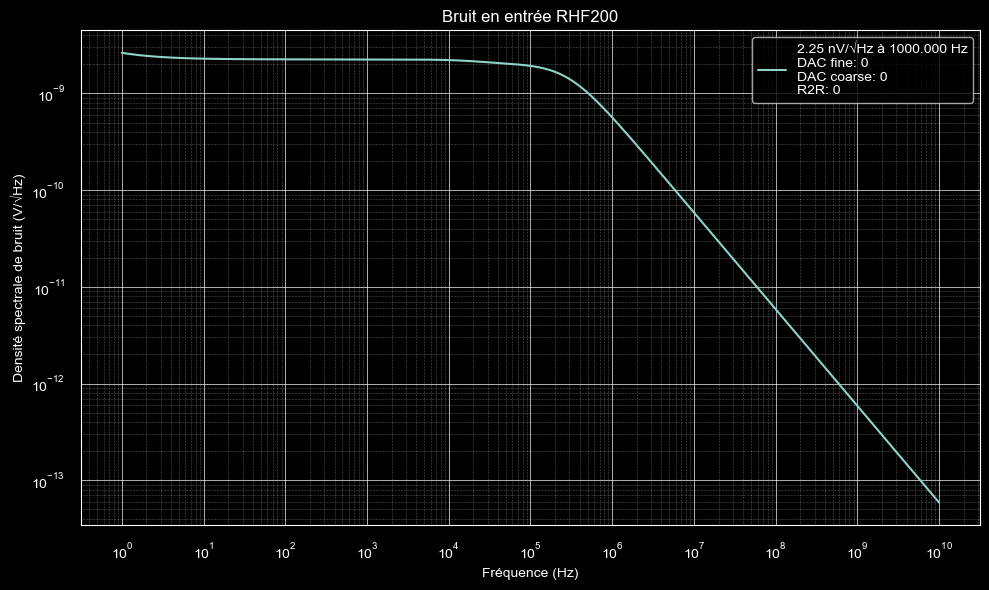

In [305]:
#bruit total en entrée RHF200
e_total_in_rhf200 = lambda w: np.sqrt(
    e_dac_fine_out(w) ** 2 + e_r4_out(w) ** 2 + e_r5_out(w) ** 2 + e_r6_out(w) ** 2 + e_r2r_out(
        w) ** 2 + e_dac_coarse_out(w) ** 2 + e_r1_out(w) ** 2
    + e_r2_out(w) ** 2 + e_r3_out(w) ** 2 + e_r14_out(w) ** 2 + e_ada4084_coarse_out(w) ** 2 + e_ada4084_fine_out(
        w) ** 2)

# --- Tracé ---
freq_print = 1e3  # fréquence pour laquelle on met la mesure du bruit en légende
w_print = 2 * np.pi * freq_print
fig, ax = plt.subplots(figsize=(10, 6))
CR = "\n"
ax.loglog(f, e_total_in_rhf200(w),
          label=f"{e_total_in_rhf200(w_print) * 1e9:.2f} nV/√Hz à {freq_print:.3f} Hz{CR}DAC fine: {code_fine}{CR}DAC coarse: {code_coarse}{CR}R2R: {code_fast}")

### Mise en forme ###
ax.set_title("Bruit en entrée RHF200")
ax.set_xlabel("Fréquence (Hz)")
ax.set_ylabel("Densité spectrale de bruit (V/√Hz)")

# grille principale
ax.grid(which='major', linestyle='-', linewidth=0.6, alpha=0.8)
# grille secondaire (optionnelle, plus discrète)
ax.grid(which='minor', linestyle=':', linewidth=0.4, alpha=0.6)

# --- FORCER les graduations secondaires (minor ticks) ---
# Major ticks : puissances de 10 (10^n)
ax.xaxis.set_major_locator(LogLocator(base=10.0, numticks=15))
ax.yaxis.set_major_locator(LogLocator(base=10.0, numticks=15))

# Minor ticks : entre 2,3,...,9 * 10^n
# Utiliser subs = np.arange(2,10) (valeurs 2..9). Certains anciens matplotlib
# acceptent subs as list/tuple; ici on passe un ndarray.
ax.xaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10), numticks=100))
ax.yaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10), numticks=100))

# Ajuster l'apparence des ticks
ax.tick_params(which='major', length=8, width=1)
ax.tick_params(which='minor', length=4, width=0.8, color='gray')

ax.legend()
plt.tight_layout()
plt.show()

### Bruit en sortie RHF200 : Modèle équivalent à une source de bruit et une résistance idéale

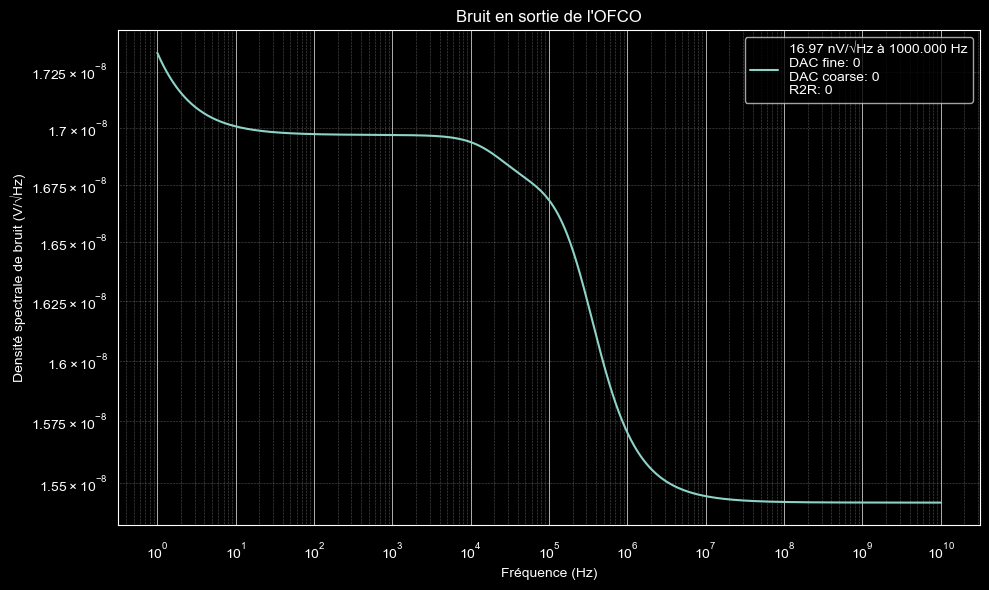

In [306]:
#Gain RHF200 de 2
gain_rhf200_ofco = 2
e_ofco = lambda w: np.sqrt(
    (gain_rhf200_ofco * (e_total_in_rhf200(w) + er15)) ** 2 + er16a ** 2 + er16b ** 2 + e_rhf_o_gain2 ** 2)

# --- Tracé ---
freq_print = 1e3  # fréquence pour laquelle on met la mesure du bruit en légende
w_print = 2 * np.pi * freq_print
fig, ax = plt.subplots(figsize=(10, 6))
ax.loglog(f, e_ofco(w),
          label=f"{e_ofco(w_print) * 1e9:.2f} nV/√Hz à {freq_print:.3f} Hz{CR}DAC fine: {code_fine}{CR}DAC coarse: {code_coarse}{CR}R2R: {code_fast}")

### Mise en forme ###
ax.set_title("Bruit en sortie de l'OFCO")
ax.set_xlabel("Fréquence (Hz)")
ax.set_ylabel("Densité spectrale de bruit (V/√Hz)")

# grille principale
ax.grid(which='major', linestyle='-', linewidth=0.6, alpha=0.8)
# grille secondaire (optionnelle, plus discrète)
ax.grid(which='minor', linestyle=':', linewidth=0.4, alpha=0.6)

# --- FORCER les graduations secondaires (minor ticks) ---
# Major ticks : puissances de 10 (10^n)
ax.xaxis.set_major_locator(LogLocator(base=10.0, numticks=15))
ax.yaxis.set_major_locator(LogLocator(base=10.0, numticks=15))

# Minor ticks : entre 2,3,...,9 * 10^n
# Utiliser subs = np.arange(2,10) (valeurs 2..9). Certains anciens matplotlib
# acceptent subs as list/tuple; ici on passe un ndarray.
ax.xaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10), numticks=100))
ax.yaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10), numticks=100))

# Ajuster l'apparence des ticks
ax.tick_params(which='major', length=8, width=1)
ax.tick_params(which='minor', length=4, width=0.8, color='gray')

ax.legend()
plt.tight_layout()
plt.show()

## Rebouclé sur ADC

In [307]:
### Résistances ###
R1_adc = 100
R2_adc = 100
R3_adc = 10e3
R4_adc = 10e3
R5_adc = 15
R6_adc = 15

er2_adc = thermal_noise(R2_adc, Celsius2Kelvin(T))
er3_adc = thermal_noise(R3_adc, Celsius2Kelvin(T))
er4_adc = thermal_noise(R4_adc, Celsius2Kelvin(T))
er5_adc = thermal_noise(R5_adc, Celsius2Kelvin(T))
er6_adc = thermal_noise(R6_adc, Celsius2Kelvin(T))

### Actifs ###
#ADC
Vpp = 2
N = 14
#quantization noise
e_adc_q, _, LSB = quantization_noise(Vpp, N, Fs)
#thermal noise
rms_adc_th = 1.25  #LSB rms
BW_adc_th_noise = 150e6 / 2  #Hz
#Input BW
ADC_BW = 650e6
tau_c_ADC = 1 / (2 * np.pi * ADC_BW)
H_ADC = lambda w: 1 / (1 + 1j * tau_c_ADC * w)
#Calcul de la densité spectrale de bruit thermique
e_adc_th_Ny = rms_adc_th * LSB / np.sqrt(BW_adc_th_noise)  #etalage sur Nyquist
Beq_th = np.pi / 2 * ADC_BW
e_adc_th = e_adc_th_Ny * np.sqrt(BW_adc_th_noise / Beq_th)  #étalage sur toute la bande vis à vis repliement

In [308]:
### Gain du LNA ###
gain_rhf_adc = 1

### Capacités de filtrage ###
C1_adc = 15e-12
C2_adc = 270e-12

### Les gains permettent de ramener les bruits en entrée de l'ADC ###

#Gain de R5 ou R6
H_R56_adc = lambda w: 1 / (1 + 1j * (R5_adc + R6_adc) * C2_adc * w) * H_ADC(w)

# Gain de R1
zequi_1 = lambda w: (R3_adc + R4_adc) * (1 + 1j * R2_adc * C1_adc * w) / (
            1 + 1j * C1_adc * (R2_adc + R3_adc + R4_adc) * w)  # impédance équivalente vue après R1
H_R1_adc = lambda w: zequi_1(w) / (R1_adc + zequi_1(w)) * gain_rhf_adc * H_R56_adc(w)

# Gain de R2
zequi_2 = 1 / (1 / R1_adc + 1 / (R3_adc + R4_adc))
H_R2_adc = lambda w: 1j * zequi_2 * C1_adc * w / (1 + 1j * (zequi_2 + R2_adc) * C1_adc * w) * gain_rhf_adc * H_R56_adc(
    w)

# Gain de R3 ou R4
zequi_3 = lambda w: R1_adc * (1 + 1j * R2_adc * C1_adc * w) / (1 + 1j * C1_adc * (R2_adc + R1_adc) * w)
H_R34_adc = lambda w: 1 / (1 + (R3_adc + R4_adc) / zequi_3(w)) * gain_rhf_adc * H_R56_adc(w)

#Gain RHF200
H_rhf_adc = lambda w: gain_rhf_adc * H_R56_adc(w)

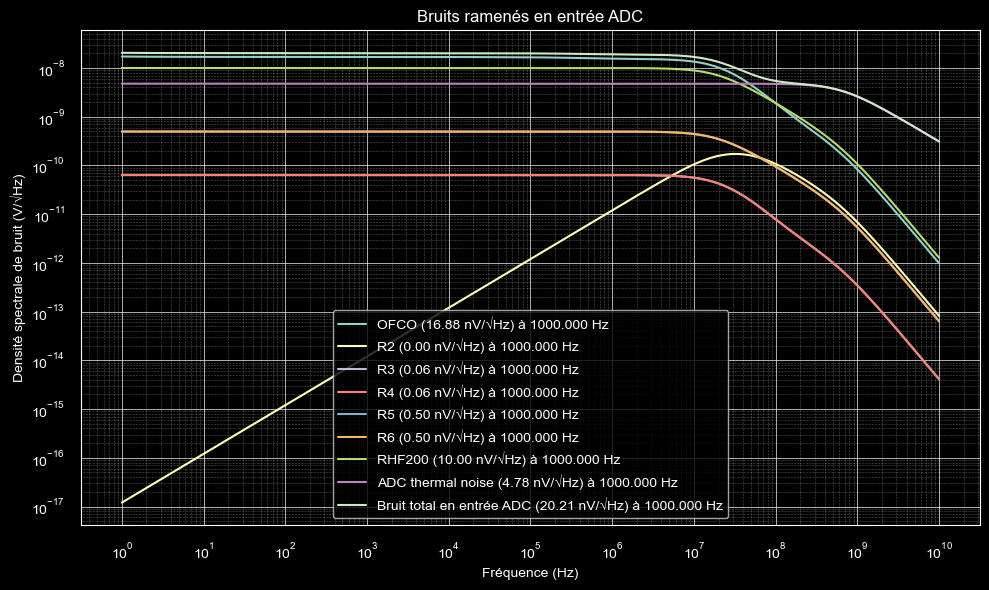

In [309]:
##### Tracé des différentes sources de bruit ####
import matplotlib.pyplot as plt
from matplotlib.ticker import LogLocator

# --- Paramètres ---
f = np.logspace(0, 10, 1000)  # 1 Hz à 10 GHz
w = 2 * np.pi * f

#Vecteurs des bruits ramenés en entrée ADC
e_ofco_out = lambda w: np.abs(H_R1_adc(w) * e_ofco(w))
er2_adc_out = lambda w: np.abs(H_R2_adc(w)) * er2_adc
er3_adc_out = lambda w: np.abs(H_R34_adc(w)) * er3_adc
er4_adc_out = lambda w: np.abs(H_R34_adc(w)) * er4_adc
er5_adc_out = lambda w: np.abs(H_R56_adc(w)) * er5_adc
er6_adc_out = lambda w: np.abs(H_R56_adc(w)) * er6_adc
erhf_adc_out = lambda w: np.abs(H_rhf_adc(w)) * e_rhf_o_gain1
e_adc_th_out = lambda w: np.abs(H_ADC(w)) * e_adc_th

e_total_in_adc = lambda w: np.sqrt(
    e_ofco_out(w) ** 2 + er2_adc_out(w) ** 2 + er3_adc_out(w) ** 2 + er4_adc_out(w) ** 2 + er5_adc_out(
        w) ** 2 + er6_adc_out(w) ** 2 + erhf_adc_out(w) ** 2 + e_adc_th_out(w) ** 2)

# --- Tracé ---
freq_print = 1e3  # fréquence pour laquelle on met la mesure du bruit en légende
w_print = 2 * np.pi * freq_print
fig, ax = plt.subplots(figsize=(10, 6))
ax.loglog(f, e_ofco_out(w), label=f"OFCO ({e_ofco_out(w_print) * 1e9:.2f} nV/√Hz) à {freq_print:.3f} Hz")
ax.loglog(f, er2_adc_out(w), label=f"R2 ({er2_adc_out(w_print) * 1e9:.2f} nV/√Hz) à {freq_print:.3f} Hz")
ax.loglog(f, er3_adc_out(w), label=f"R3 ({er3_adc_out(w_print) * 1e9:.2f} nV/√Hz) à {freq_print:.3f} Hz")
ax.loglog(f, er4_adc_out(w), label=f"R4 ({er4_adc_out(w_print) * 1e9:.2f} nV/√Hz) à {freq_print:.3f} Hz")
ax.loglog(f, er5_adc_out(w), label=f"R5 ({er5_adc_out(w_print) * 1e9:.2f} nV/√Hz) à {freq_print:.3f} Hz")
ax.loglog(f, er6_adc_out(w), label=f"R6 ({er6_adc_out(w_print) * 1e9:.2f} nV/√Hz) à {freq_print:.3f} Hz")
ax.loglog(f, erhf_adc_out(w), label=f"RHF200 ({erhf_adc_out(w_print) * 1e9:.2f} nV/√Hz) à {freq_print:.3f} Hz")
ax.loglog(f, e_adc_th_out(w),
          label=f"ADC thermal noise ({e_adc_th_out(w_print) * 1e9:.2f} nV/√Hz) à {freq_print:.3f} Hz")
ax.loglog(f, e_total_in_adc(w),
          label=f"Bruit total en entrée ADC ({e_total_in_adc(w_print) * 1e9:.2f} nV/√Hz) à {freq_print:.3f} Hz")

### Mise en forme ###
ax.set_title("Bruits ramenés en entrée ADC")
ax.set_xlabel("Fréquence (Hz)")
ax.set_ylabel("Densité spectrale de bruit (V/√Hz)")

# grille principale
ax.grid(which='major', linestyle='-', linewidth=0.6, alpha=0.8)
# grille secondaire (optionnelle, plus discrète)
ax.grid(which='minor', linestyle=':', linewidth=0.4, alpha=0.6)

# --- FORCER les graduations secondaires (minor ticks) ---
# Major ticks : puissances de 10 (10^n)
ax.xaxis.set_major_locator(LogLocator(base=10.0, numticks=15))
ax.yaxis.set_major_locator(LogLocator(base=10.0, numticks=15))

# Minor ticks : entre 2,3,...,9 * 10^n
# Utiliser subs = np.arange(2,10) (valeurs 2..9). Certains anciens matplotlib
# acceptent subs as list/tuple; ici on passe un ndarray.
ax.xaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10), numticks=100))
ax.yaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10), numticks=100))

# Ajuster l'apparence des ticks
ax.tick_params(which='major', length=8, width=1)
ax.tick_params(which='minor', length=4, width=0.8, color='gray')

ax.legend()
plt.tight_layout()
plt.show()

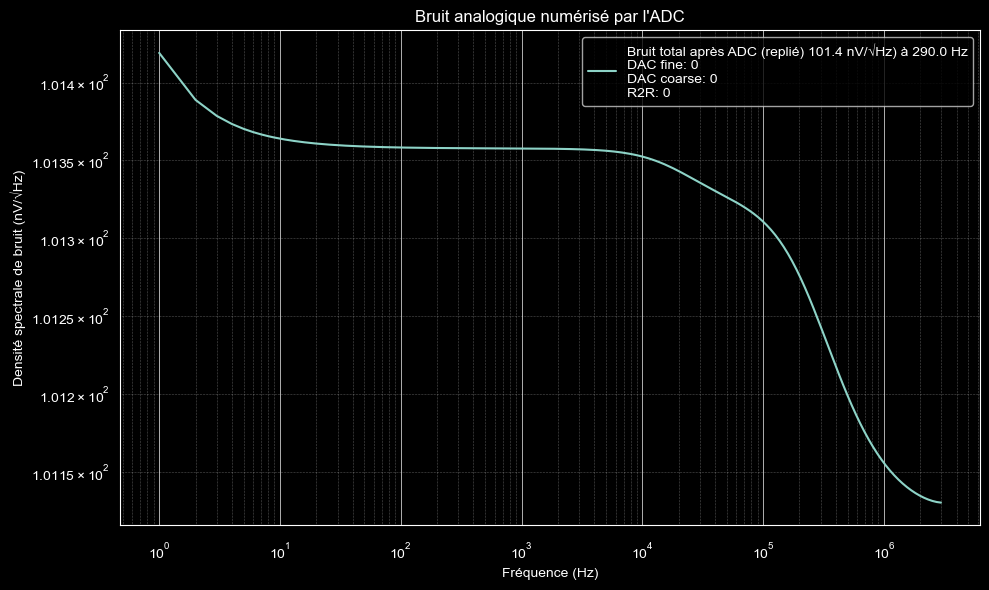

In [310]:
### Bruit replié par échantillonage ###

# ==== PARAMÈTRES ====
fmax = 100e9  # domaine fréquentiel du système analogique (Hz)
N_num = 200  # nombre de points en numérique sur Fs/2

f_num, e_fold = aliasing(e_total_in_adc, fmax, Fs, N_num)

# ==== AFFICHAGE ====
N_print = 50
freq_print = f_num[N_print]
fig, ax = plt.subplots(figsize=(10, 6))
ax.loglog(f_num, e_fold * 1e9,
          label=f"Bruit total après ADC (replié) {e_fold[N_print] * 1e9:.1f} nV/√Hz) à {freq_print:.1f} Hz{CR}DAC fine: {code_fine}{CR}DAC coarse: {code_coarse}{CR}R2R: {code_fast}")
#ax.loglog(f_num, np.ones_like(f_num),label=f"Bruit avant repliement {1}")

### Mise en forme ###
ax.set_title("Bruit analogique numérisé par l'ADC")
ax.set_xlabel("Fréquence (Hz)")
ax.set_ylabel("Densité spectrale de bruit (nV/√Hz)")

# grille principale
ax.grid(which='major', linestyle='-', linewidth=0.6, alpha=0.8)
# grille secondaire (optionnelle, plus discrète)
ax.grid(which='minor', linestyle=':', linewidth=0.4, alpha=0.6)

# --- FORCER les graduations secondaires (minor ticks) ---
# Major ticks : puissances de 10 (10^n)
ax.xaxis.set_major_locator(LogLocator(base=10.0, numticks=15))
ax.yaxis.set_major_locator(LogLocator(base=10.0, numticks=15))

# Minor ticks : entre 2,3,...,9 * 10^n
# Utiliser subs = np.arange(2,10) (valeurs 2..9). Certains anciens matplotlib
# acceptent subs as list/tuple; ici on passe un ndarray.
ax.xaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10), numticks=100))
ax.yaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10), numticks=100))

# Ajuster l'apparence des ticks
ax.tick_params(which='major', length=8, width=1)
ax.tick_params(which='minor', length=4, width=0.8, color='gray')

ax.legend()
plt.tight_layout()
plt.show()

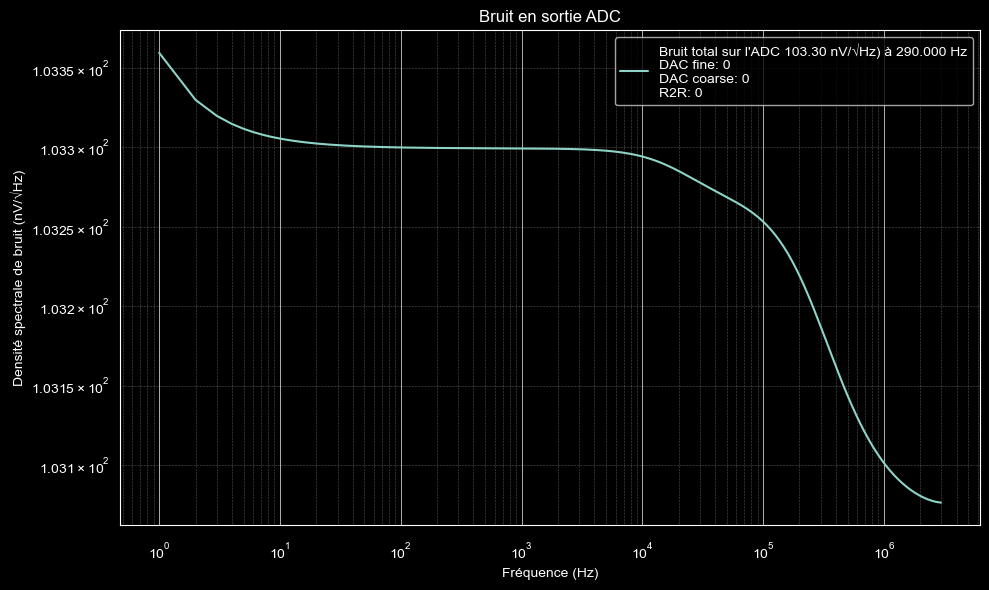

In [311]:
# ajout du bruit de quantification

e_total = np.sqrt(np.ones_like(f_num) * e_adc_q ** 2 + e_fold ** 2)

# ==== AFFICHAGE ====
N_print = 50
freq_print = f_num[N_print]
fig, ax = plt.subplots(figsize=(10, 6))
ax.loglog(f_num, e_total * 1e9,
          label=f"Bruit total sur l'ADC {e_total[N_print] * 1e9:.2f} nV/√Hz) à {freq_print:.3f} Hz{CR}DAC fine: {code_fine}{CR}DAC coarse: {code_coarse}{CR}R2R: {code_fast}")

### Mise en forme ###
ax.set_title("Bruit en sortie ADC")
ax.set_xlabel("Fréquence (Hz)")
ax.set_ylabel("Densité spectrale de bruit (nV/√Hz)")

# grille principale
ax.grid(which='major', linestyle='-', linewidth=0.6, alpha=0.8)
# grille secondaire (optionnelle, plus discrète)
ax.grid(which='minor', linestyle=':', linewidth=0.4, alpha=0.6)

# --- FORCER les graduations secondaires (minor ticks) ---
# Major ticks : puissances de 10 (10^n)
ax.xaxis.set_major_locator(LogLocator(base=10.0, numticks=15))
ax.yaxis.set_major_locator(LogLocator(base=10.0, numticks=15))

# Minor ticks : entre 2,3,...,9 * 10^n
ax.xaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10), numticks=100))
ax.yaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10), numticks=100))

# Ajuster l'apparence des ticks
ax.tick_params(which='major', length=8, width=1)
ax.tick_params(which='minor', length=4, width=0.8, color='gray')

ax.legend()
plt.tight_layout()
plt.show()


In [312]:
export_2vectors_to_file(f_num, e_total, data_filename)
